In [198]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp
from scipy.stats import ttest_ind
import numpy as np
from statsmodels.stats.multitest import multipletests

In [656]:
SAM_number = 10.5
FDA_number = 3.108

## Single Mutants

In [657]:
# Get csv file 
relact_raw = pd.read_csv("data/FlA_ZP_RelAct_full.csv", sep=";")
relact_raw['FDA_conc'] = FDA_number*(relact_raw['FDA_Area'])
relact_raw['SAM_conc'] = SAM_number*(relact_raw['SAM_Area'])
relact_raw["%SAM_converted"] = relact_raw['FDA_conc'] / (relact_raw['FDA_conc'] + relact_raw['SAM_conc']) * 100

# Filter for the reference condition (Protein == "WT")
reference = relact_raw[relact_raw["Protein"] == "WT"]

# Merge the reference values back into the original DataFrame based on the same condition
relact = relact_raw.merge(
    reference[["Plate", "Time(min)", "SAM_conc(uM)", "Replicate", "%SAM_converted"]],
    on=["Plate", "Time(min)", "SAM_conc(uM)", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# Calculate Relative_Activity
relact["Relative_Activity"] = relact["%SAM_converted"] / relact["%SAM_converted_ref"]

# Drop the intermediate reference column 
relact.drop(columns=["%SAM_converted_ref"], inplace=True)

relact_var = relact.drop(relact.index[relact["Protein"] == "WT"].tolist())

In [658]:
SAM = 300
t = 2
subset_2 = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

t = 180
subset_180 = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

ref_2 = subset_2[subset_2["Protein"] == "WT"]
wt_conv_2 = ref_2['%SAM_converted'].values
wt_mean_2 = np.mean(wt_conv_2)

subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2

ref_180 = subset_180[subset_180["Protein"] == "WT"]
wt_conv_180 = ref_180['%SAM_converted'].values
wt_mean_180 = np.mean(wt_conv_180)

subset_180['Relative_Activity'] = subset_180['%SAM_converted'] / wt_mean_180

relact['Relative_Activity'] = [subset_2['Relative_Activity'][i] if (relact['Time(min)'][i]==2 and relact['SAM_conc(uM)'][i]==300) else subset_180['Relative_Activity'][i] if (relact['Time(min)'][i]==180 and relact['SAM_conc(uM)'][i]==300) else np.nan for i in range(len(relact))]

ref_2 = relact[relact["Protein"] == "WT"][relact["Time(min)"] == 2][relact["SAM_conc(uM)"] == 300]
ref_2_std = ref_2.Relative_Activity.std()
ref_180 = relact[relact["Protein"] == "WT"][relact["Time(min)"] == 180][relact["SAM_conc(uM)"] == 300]
ref_180_std = ref_180.Relative_Activity.std()

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/658844233.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2['Relative_Activity'] = subset_2['%SAM_converted'] / wt_mean_2
/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/658844233.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_180['Relative_Activity'] = subset_180['%SAM_converted'] / wt_mean_180
/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/658844233.py:22: UserWarning: Boolean Serie

In [659]:
# Get csv file with model rankings
ZP_pred = pd.read_csv("data/FlA_HIM_SMscan_full_sorted_ESM1b&TranceptEVE&ESM-IF1.csv", sep=";") 

# Add bin and rank columns for each model
relact_var_models = relact.merge(#relact_var.merge(#
    ZP_pred[["mutant", "ESM1b_bin", "ESM1b_rank", "ESM1b_score", "TranceptEVE_bin", "TranceptEVE_rank", "TranceptEVE_score", "ESM-IF1_bin", "ESM-IF1_rank", "ESM-IF1_score"]],
    left_on="Protein", right_on="mutant",
    how="left"
)

relact_var_models = relact_var_models.dropna(subset="mutant") ### drop all variants that werent in the dataset predicted by the ZSM

relact_var_models.drop(columns=["mutant"], inplace=True)

# Add selection metrics for testing 
singles = ["ESM1b", "TranceptEVE", "ESM-IF1"]
doubles = ["ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]

for model in singles:
    relact_var_models[model] = [True if rank <= 10 else False for rank in relact_var_models[f"{model}_rank"]] ### if rank is equal to or higher than 10, counts to that model
    
for model in doubles:
    bins = model.split("_")
    relact_var_models[model] = False ### initialize column
    relact_var_models.loc[(relact_var_models[f"{bins[0]}_bin"] == 1) & (relact_var_models[f"{bins[1]}_bin"] == 1), model] = True ### if both models predict as faster variant, counts to that model


# Get TranceptEVE_ESM-IF1 combined rank score
relact_var_models["ESM1b_TranceptEVE_rank"] = relact_var_models["ESM1b_rank"] + relact_var_models["TranceptEVE_rank"]
relact_var_models["ESM1b_ESM-IF1_rank"] = relact_var_models["ESM1b_rank"] + relact_var_models["ESM-IF1_rank"]
relact_var_models["TranceptEVE_ESM-IF1_rank"] = relact_var_models["TranceptEVE_rank"] + relact_var_models["ESM-IF1_rank"]

relact_var_models["TranceptEVE_ESM-IF1"] = [True if rank <= 116 else False for rank in relact_var_models["TranceptEVE_ESM-IF1_rank"]] ### Special treatment for this combination: only top ten when combining rankings are included in model     

In [660]:
### Save intermediate dataset
relact_var_models.to_csv("data/FlA_ZP_Relact_var.csv")

In [661]:
### Add Abou's dataset to the DataFrame
abou_data = pd.read_csv("data/FlA_HIM_relativeActivity.csv", sep=";")
temp = pd.DataFrame({
    "Sample_ID": abou_data["Name"].tolist(), 
    "Relative_Activity": abou_data["Relative activity (%)"].tolist()
})

### Convert from percentage
temp["Relative_Activity"] = temp["Relative_Activity"]/100

relact_comb = pd.concat([relact_var_models, temp], ignore_index=True)

### Add reaction data
relact_comb["Time(min)"] = relact_comb["Time(min)"].fillna(180)
relact_comb["SAM_conc(uM)"] = relact_comb["SAM_conc(uM)"].fillna(300)

### Assign false for all models 
models = ["ESM1b", "TranceptEVE", "ESM-IF1", "ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]
for model in models:
    relact_comb[model] = relact_comb[model].fillna(False)

### Create new category for selection dataset
relact_comb["Selection_Dataset"] = False
relact_comb["Selection_Dataset"] = relact_comb["Sample_ID"].str.contains("HiM", case=False)

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/395057998.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  relact_comb[model] = relact_comb[model].fillna(False)


In [662]:
#Set timepoint and SAM conc.
t=2 # [2,5,180]
SAM=300 # [10,300]

#Plotting - boxplot over different models
subset_2 = relact_comb.loc[(relact_comb["Time(min)"] == t) & (relact_comb["SAM_conc(uM)"] == SAM)]
subset_2_ordered = pd.DataFrame(
    {
        "Selection": subset_2.loc[subset_2["Selection_Dataset"], "Relative_Activity"],
        "ESM1b": subset_2.loc[subset_2["ESM1b"], "Relative_Activity"],
        "TranceptEVE": subset_2.loc[subset_2["TranceptEVE"], "Relative_Activity"],
        "ESM-IF1": subset_2.loc[subset_2["ESM-IF1"], "Relative_Activity"],
        "ESM1b_TranceptEVE": subset_2.loc[subset_2["ESM1b_TranceptEVE"], "Relative_Activity"],
        "ESM1b_ESM-IF1": subset_2.loc[subset_2["ESM1b_ESM-IF1"], "Relative_Activity"],
        "TranceptEVE_ESM-IF1": subset_2.loc[subset_2["TranceptEVE_ESM-IF1"], "Relative_Activity"]
    }
)


#Set timepoint and SAM conc.
t=180 # [2,5,180]
SAM=300 # [10,300]

#Plotting - boxplot over different models
subset_180 = relact_comb.loc[(relact_comb["Time(min)"] == t) & (relact_comb["SAM_conc(uM)"] == SAM)]
subset_180_ordered = pd.DataFrame(
    {
        "Selection": subset_180.loc[subset_180["Selection_Dataset"], "Relative_Activity"],
        "ESM1b": subset_180.loc[subset_180["ESM1b"], "Relative_Activity"],
        "TranceptEVE": subset_180.loc[subset_180["TranceptEVE"], "Relative_Activity"],
        "ESM-IF1": subset_180.loc[subset_180["ESM-IF1"], "Relative_Activity"],
        "ESM1b_TranceptEVE": subset_180.loc[subset_180["ESM1b_TranceptEVE"], "Relative_Activity"],
        "ESM1b_ESM-IF1": subset_180.loc[subset_180["ESM1b_ESM-IF1"], "Relative_Activity"],
        "TranceptEVE_ESM-IF1": subset_180.loc[subset_180["TranceptEVE_ESM-IF1"], "Relative_Activity"]
    }
)

In [663]:
subset_180_mean = {}
subset_180_std = {}
subset_2_mean = {}
subset_2_std = {}
models = ["ESM1b", "TranceptEVE", "ESM-IF1", "ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]
for model in models:
    mean_ = [subset_180.loc[subset_180["Protein"] == prot, "Relative_Activity"].mean() for prot in pd.unique(subset_180.loc[subset_180[model], ["Relative_Activity",'Protein']].Protein)]
    std_ = [subset_180.loc[subset_180["Protein"] == prot, "Relative_Activity"].std() for prot in pd.unique(subset_180.loc[subset_180[model], ["Relative_Activity",'Protein']].Protein)]
    subset_180_mean[model] = mean_
    subset_180_std[model] = std_

    mean_ = [subset_2.loc[subset_2["Protein"] == prot, "Relative_Activity"].mean() for prot in pd.unique(subset_2.loc[subset_2[model], ["Relative_Activity",'Protein']].Protein)]
    std_ = [subset_2.loc[subset_2["Protein"] == prot, "Relative_Activity"].std() for prot in pd.unique(subset_2.loc[subset_2[model], ["Relative_Activity",'Protein']].Protein)]
    subset_2_mean[model] = mean_
    subset_2_std[model] = std_

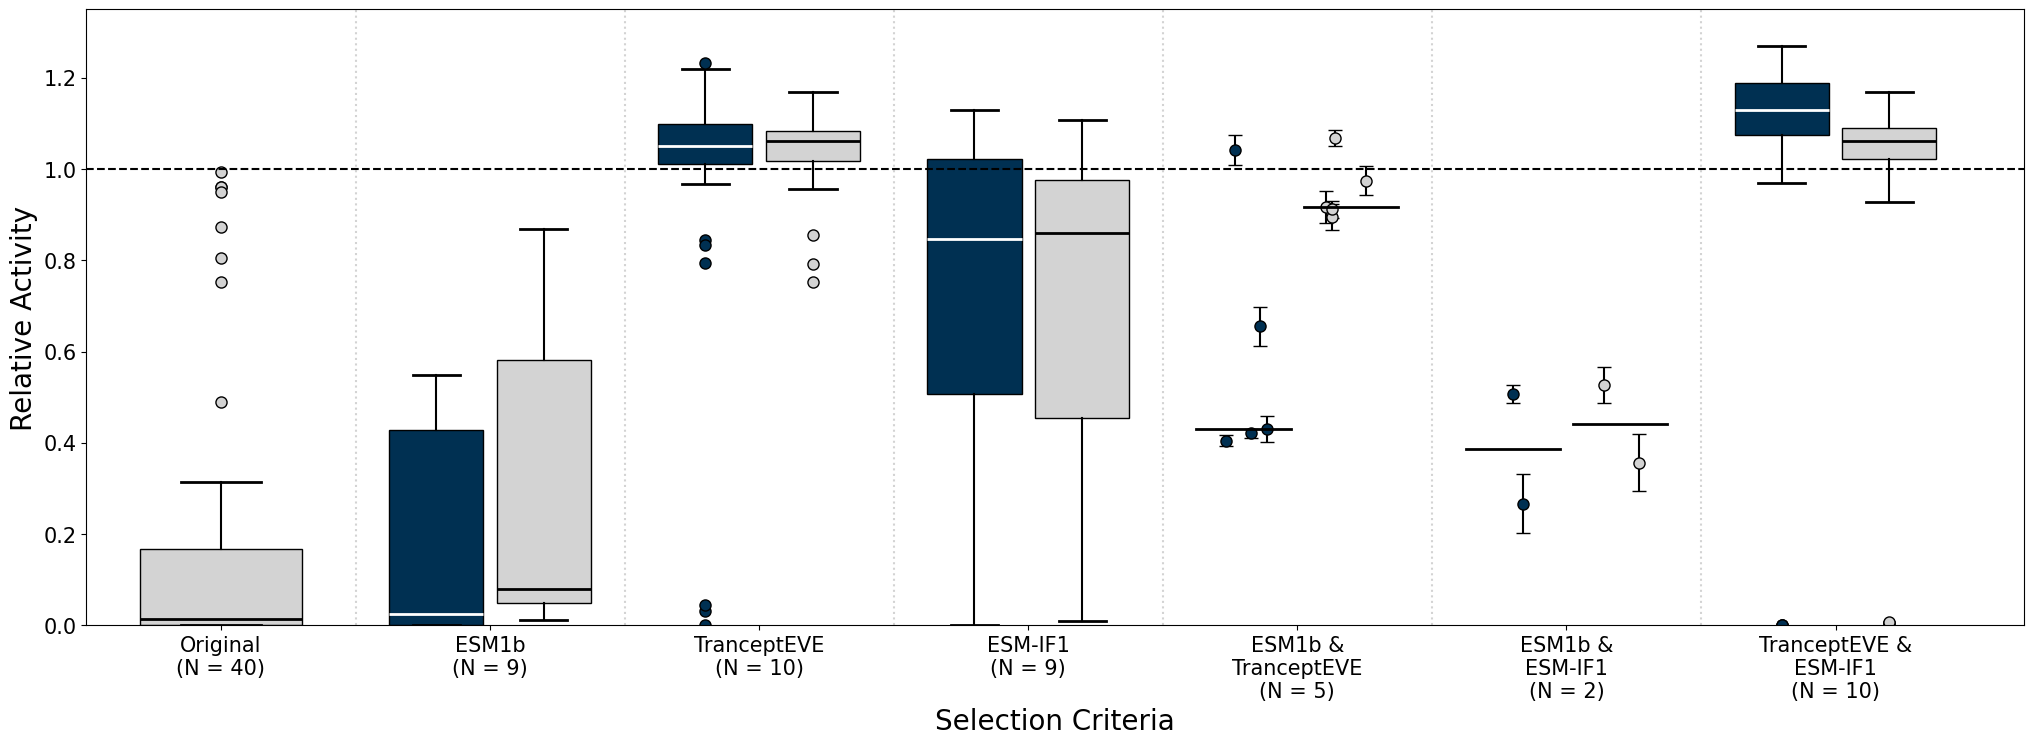

In [664]:

#color_ = ['#516F84', '#DF9966']
#color_ = ['#DF9966', 'lightgrey']
color_ = ['lightgrey','#003052']

fig, ax = plt.subplots(figsize=(25, 8))
ax.boxplot(subset_180_ordered.Selection.dropna(),positions=[0],
            patch_artist=True,  # Allows color filling
            boxprops=dict(facecolor=color_[0], color='k'),  # Box fill & outline color
            whiskerprops=dict(color="black", linewidth=1.5),  # Whisker color
            capprops=dict(color="k", linewidth=2),  # Cap (end line) color
            medianprops=dict(color="black", linewidth=2),  # Median line color
            flierprops=dict(marker="o", markerfacecolor=color_[0], markeredgecolor="black", markersize=8),  # Outlier style
            widths=0.6  # Width of the box
            )
x_positions = range(1, len(subset_180_ordered.columns[1:]) + 1)
for i, col in enumerate(subset_180_ordered.columns[1:]):
    if col != 'ESM1b_ESM-IF1' and col != 'ESM1b_TranceptEVE':
        box = ax.boxplot(subset_180_ordered[col].dropna(),positions=[x_positions[i]+0.2],
                        patch_artist=True,  # Allows color filling
                        boxprops=dict(facecolor=color_[0], color='k'),  # Box fill & outline color
                        whiskerprops=dict(color="black", linewidth=1.5),  # Whisker color
                        capprops=dict(color="k", linewidth=2),  # Cap (end line) color
                        medianprops=dict(color="black", linewidth=2),  # Median line color
                        flierprops=dict(marker="o", markerfacecolor=color_[0], markeredgecolor="black", markersize=8),  # Outlier style
                        widths=0.35,  # Width of the box
                        )
        box = ax.boxplot(subset_2_ordered[col].dropna(),positions=[x_positions[i]-0.2],
                        patch_artist=True,  # Allows color filling
                        boxprops=dict(facecolor=color_[1], color='k'),  # Box fill & outline color
                        whiskerprops=dict(color="black", linewidth=1.5),  # Whisker color
                        capprops=dict(color="k", linewidth=2),  # Cap (end line) color
                        medianprops=dict(color="white", linewidth=2),  # Median line color
                        flierprops=dict(marker="o", markerfacecolor=color_[1], markeredgecolor="black", markersize=8),  # Outlier style
                        widths=0.35,  # Width of the box
                        )
    else:
        ax.errorbar(i+1+0.2+np.random.uniform(low=-1,high=1,size=len(subset_180_mean[col]))/10, y=subset_180_mean[col], yerr=subset_180_std[col], fmt='o',
                    markerfacecolor=color_[0], markeredgecolor='black', ecolor='k', capsize=5, markersize=8,zorder=1)
        ax.errorbar(i+1-0.2+np.random.uniform(low=-1,high=1,size=len(subset_2_mean[col]))/10, y=subset_2_mean[col], yerr=subset_2_std[col], fmt='o',
                    markerfacecolor=color_[1], markeredgecolor='black', ecolor='k', capsize=5, markersize=8,zorder=1)
        ax.plot([i+1+0.2-0.175,i+1+0.2+0.175],[np.median(subset_180_mean[col]),np.median(subset_180_mean[col])],color='k',linewidth=2,zorder=2)
        ax.plot([i+1-0.2-0.175,i+1-0.2+0.175],[np.median(subset_2_mean[col]),np.median(subset_2_mean[col])],color='k',linewidth=2,zorder=2)
    
for i in range(6):
    ax.axvline(x=i+0.5, color='lightgray', linestyle=':')
ax.axhline(y=1, color='black', linestyle='--')

x_labels = ['Original\n(N = 40)', 'ESM1b\n(N = 9)', 'TranceptEVE\n(N = 10)', 'ESM-IF1\n(N = 9)', 'ESM1b &\nTranceptEVE\n(N = 5)', 'ESM1b &\nESM-IF1\n(N = 2)', 'TranceptEVE &\nESM-IF1\n(N = 10)']
ax.set_xticks(np.arange(7))
ax.set_xticklabels(x_labels, fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel("Selection Criteria", fontsize=20)
ax.set_ylabel("Relative Activity", fontsize=20)
ax.set_ylim(0, 1.35)
#plt.title("Boxplot of Different Groups")
plt.show()

In [665]:
rows_2min = []

single_models=["ESM1b", "TranceptEVE", "ESM-IF1"]
double_models=["ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]

for model in single_models + double_models:
    subset = relact_var_models.loc[
        relact_var_models[model] &
        (relact_var_models["Time(min)"] == 2) &
        (relact_var_models["SAM_conc(uM)"] == SAM)
    ]

    for mut in subset.Protein.unique():
        act_ = subset.loc[subset.Protein == mut, "Relative_Activity"]
        if not act_.empty:
            rows_2min.append({
                "mut": mut,
                "act_mean": act_.mean(),
                "act_std": act_.std(),
                "model": model
            })

all_results_2min = pd.DataFrame(rows_2min).sort_values(by="act_mean", ascending=False).reset_index(drop=True)


In [666]:
t = 2
sam = 300
subset = relact_var_models.loc[(relact_var_models["Time(min)"] == t) & (relact_var_models["SAM_conc(uM)"] == sam)]
sm_act_2_replicate = []
for prot in pd.unique(subset.Protein):
    subset_ = subset.loc[subset.Protein == prot]
    for rep in pd.unique(subset_.Replicate):
        act_ = subset_[subset_.Replicate == rep].Relative_Activity.values[0]
        sm_act_2_replicate.append([prot,act_,rep])
sm_act_2_replicate = pd.DataFrame(sm_act_2_replicate, columns=["Protein", "Relative_Activity", "Replicate"])

t= 180
sam = 300
subset = relact_var_models.loc[(relact_var_models["Time(min)"] == t) & (relact_var_models["SAM_conc(uM)"] == sam)]
sm_act_180_replicate = []
for prot in pd.unique(subset.Protein):
    subset_ = subset.loc[subset.Protein == prot]
    for rep in pd.unique(subset_.Replicate):
        act_ = subset_[subset_.Replicate == rep].Relative_Activity.values[0]
        sm_act_180_replicate.append([prot,act_,rep])
sm_act_180_replicate = pd.DataFrame(sm_act_180_replicate, columns=["Protein", "Relative_Activity", "Replicate"])


In [667]:
unique_rows = []
for mut, group in all_results_2min.groupby("mut"):
    if len(group) > 1:
        subset_double_model = group[group.model.str.contains("_", na=False)]
        model_val = subset_double_model.model.iloc[0] if not subset_double_model.empty else None
        unique_rows.append({
            "mut": mut,
            "act_mean": group.act_mean.mean(),
            "act_std": group.act_std.mean(),
            "model": model_val
        })
    else:
        row = group.iloc[0]
        unique_rows.append({
            "mut": mut,
            "act_mean": row.act_mean,
            "act_std": row.act_std,
            "model": row.model
        })

unique_results_2min = pd.DataFrame(unique_rows).sort_values(by="act_mean", ascending=False).reset_index(drop=True)


In [668]:
rows_180min = []

for model in single_models + double_models:
    subset = relact_var_models.loc[
        relact_var_models[model] &
        (relact_var_models["Time(min)"] == 180) &
        (relact_var_models["SAM_conc(uM)"] == SAM)
    ]

    for mut in subset.Protein.unique():
        act_ = subset.loc[subset.Protein == mut, "Relative_Activity"]
        if not act_.empty:
            rows_180min.append({
                "mut": mut,
                "act_mean": act_.mean(),
                "act_std": act_.std(),
                "model": model
            })

all_results_180min = pd.DataFrame(rows_180min).sort_values(by="act_mean", ascending=False).reset_index(drop=True)

In [669]:
unique_rows = []
for mut, group in all_results_180min.groupby("mut"):
    if len(group) > 1:
        subset_double_model = group[group.model.str.contains("_", na=False)]
        model_val = subset_double_model.model.iloc[0] if not subset_double_model.empty else None
        unique_rows.append({
            "mut": mut,
            "act_mean": group.act_mean.mean(),
            "act_std": group.act_std.mean(),
            "model": model_val
        })
    else:
        row = group.iloc[0]
        unique_rows.append({
            "mut": mut,
            "act_mean": row.act_mean,
            "act_std": row.act_std,
            "model": row.model
        })

unique_results_180min = pd.DataFrame(unique_rows).sort_values(by="act_mean", ascending=False).reset_index(drop=True)

In [670]:
results = []
sig_threshold = 0.05
for name, group in sm_act_2_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_2.Relative_Activity.values)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

sm_act_2_res_df = pd.DataFrame(results)

results = []
for name, group in sm_act_180_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_180.Relative_Activity.values)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

sm_act_180_res_df = pd.DataFrame(results)

In [671]:
results = []
sig_threshold = 0.05
for name, group in sm_act_2_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_1samp(rel_activities, popmean=1.0)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

sm_act_2_res_df = pd.DataFrame(results)

results = []
for name, group in sm_act_180_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_1samp(rel_activities, popmean=1.0)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

sm_act_180_res_df = pd.DataFrame(results)

In [672]:
results = []
sig_threshold = 0.05
for name, group in sm_act_2_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_2.Relative_Activity.values)
    
    # One-sided test (mutant < WT)
    if t_stat < 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better
    

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

sm_act_2_res_neg_df = pd.DataFrame(results)

In [673]:
unique_results_2min['Relative_Activity'] = unique_results_2min['act_mean'].apply(lambda x: f"{x*100:.2f}")
unique_results_2min['Relative_Activity_std'] = unique_results_2min['act_std'].apply(lambda x: f"{x*100:.2f}")

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/491642548.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(row.mut, 1.33, color='red', s=100, edgecolor='black', marker='x', zorder=3)
/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/491642548.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(unique_results_2min.mut, rotation=90)


(-1.0, 40.0)

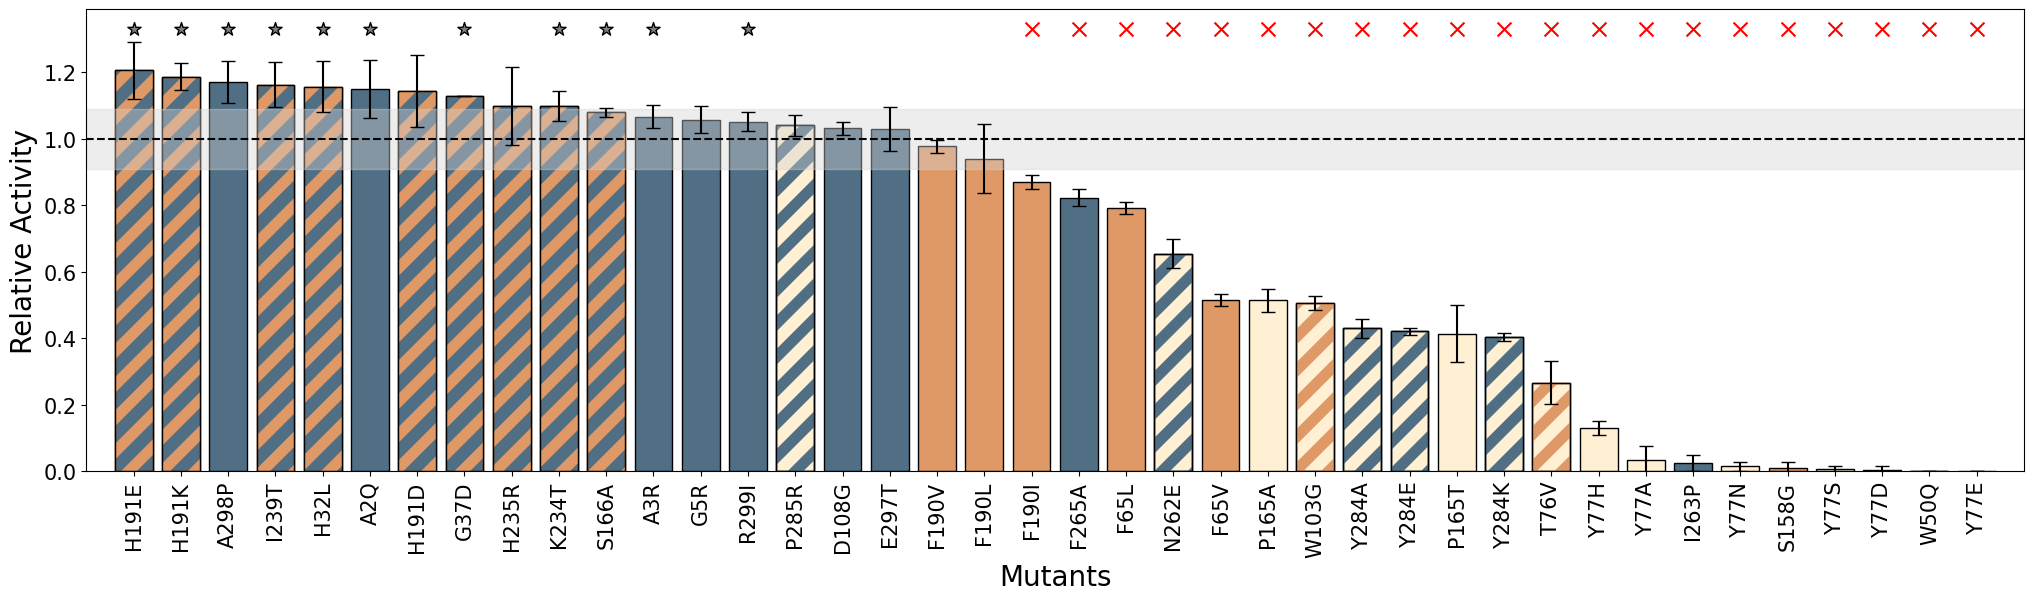

In [674]:
fig, ax= plt.subplots(figsize=(25,6))
plt.rcParams['hatch.linewidth'] = 8  # Adjust thickness of hatches
for row in unique_results_2min.itertuples():
    if row.model in single_models:
        ax.bar(row.mut, row.act_mean, yerr=row.act_std, capsize=5,
                edgecolor='black', color=model_color[row.model])
    else:
        ax.bar(row.mut, row.act_mean, yerr=row.act_std, capsize=5,
                edgecolor='black', color=model_color[row.model.split("_")[0]])
        ax.bar(row.mut, row.act_mean, color='none',hatch='/',
                edgecolor=model_color[row.model.split("_")[1]])
        ax.bar(row.mut, row.act_mean, color='none',edgecolor='black')

    significant = sm_act_2_res_df.loc[sm_act_2_res_df.Mutant == row.mut, "Significant"].values[0]

    if significant:
        ax.scatter(row.mut, 1.33, color='grey', s=100, edgecolor='black', marker='*', zorder=3)

    significant_neg = sm_act_2_res_neg_df.loc[sm_act_2_res_neg_df.Mutant == row.mut, "Significant"].values[0]
    if significant_neg:
        ax.scatter(row.mut, 1.33, color='red', s=100, edgecolor='black', marker='x', zorder=3)

ax.axhline(y=1, color='black', linestyle='--')
ax.fill_between([-1, len(unique_results_2min.mut)], 1 - ref_2_std, 1 + ref_2_std, color='lightgrey', alpha=0.4)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xticklabels(unique_results_2min.mut, rotation=90)
ax.set_xlabel("Mutants", fontsize=20)
ax.set_ylabel("Relative Activity", fontsize=20)
ax.set_ylim(0, 1.39)
ax.set_xlim(-1, len(unique_results_2min.mut))

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/4011619480.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(unique_results_180min.mut, rotation=90)


(-1.0, 40.0)

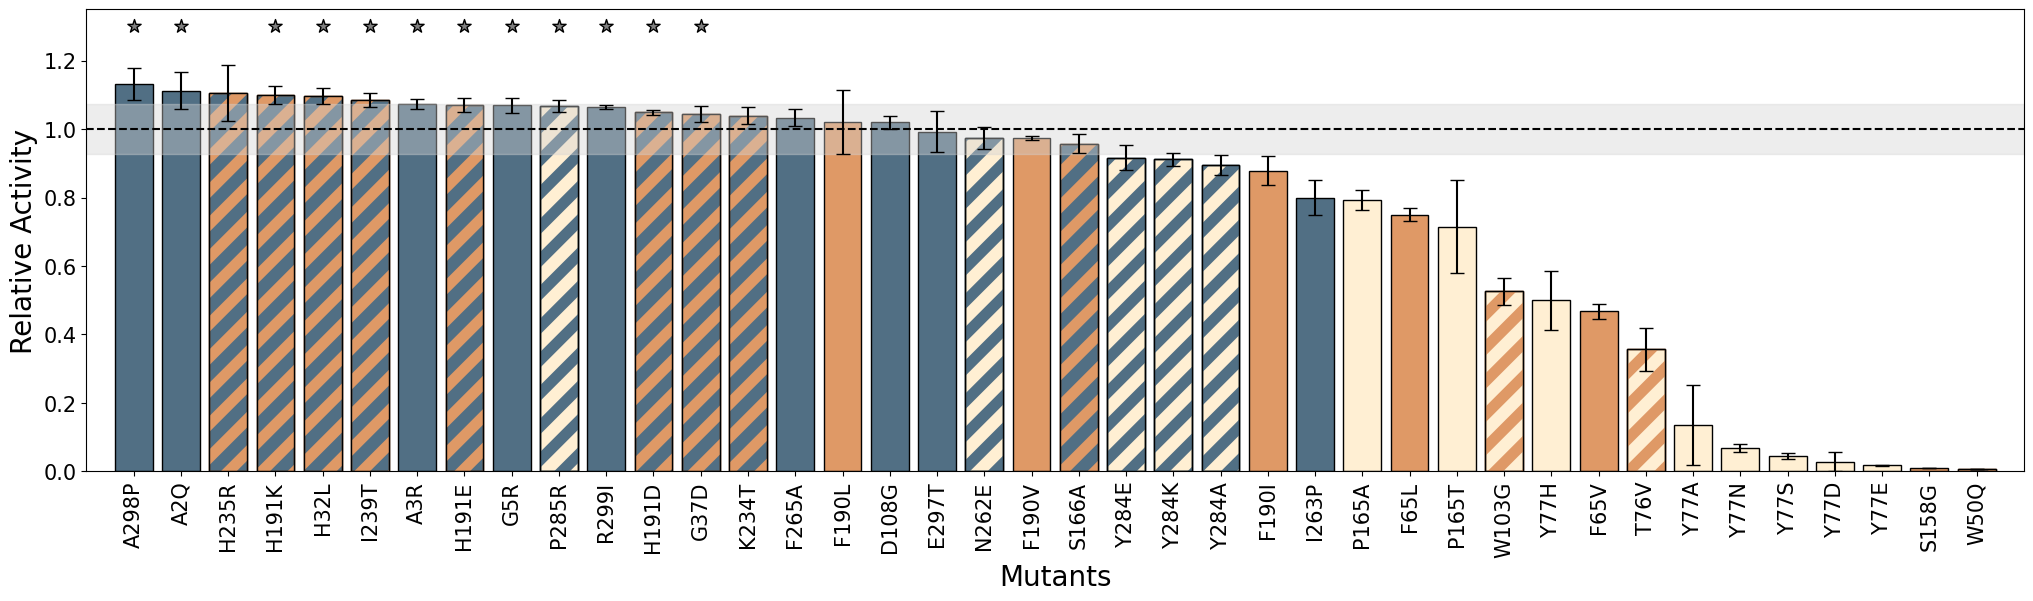

In [675]:
fig, ax= plt.subplots(figsize=(25,6))
plt.rcParams['hatch.linewidth'] = 8  # Adjust thickness of hatches
for row in unique_results_180min.itertuples():
    if row.model in single_models:
        ax.bar(row.mut, row.act_mean, yerr=row.act_std, capsize=5,
                edgecolor='black', color=model_color[row.model])
    else:
        ax.bar(row.mut, row.act_mean, yerr=row.act_std, capsize=5,
                edgecolor='black', color=model_color[row.model.split("_")[0]])
        ax.bar(row.mut, row.act_mean, color='none',hatch='/',
                edgecolor=model_color[row.model.split("_")[1]])
        ax.bar(row.mut, row.act_mean, color='none',edgecolor='black')

    significant = sm_act_180_res_df.loc[sm_act_180_res_df.Mutant == row.mut, "Significant"].values[0]

    if significant:
        ax.scatter(row.mut, 1.3, color='grey', s=100, edgecolor='black', marker='*', zorder=3)

ax.axhline(y=1, color='black', linestyle='--')
ax.fill_between([-1, len(unique_results_180min.mut)], 1 - ref_180_std, 1 + ref_180_std, color='lightgrey', alpha=0.4)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xticklabels(unique_results_180min.mut, rotation=90)
ax.set_xlabel("Mutants", fontsize=20)
ax.set_ylabel("Relative Activity", fontsize=20)
ax.set_ylim(0, 1.35)
ax.set_xlim(-1, len(unique_results_2min.mut))

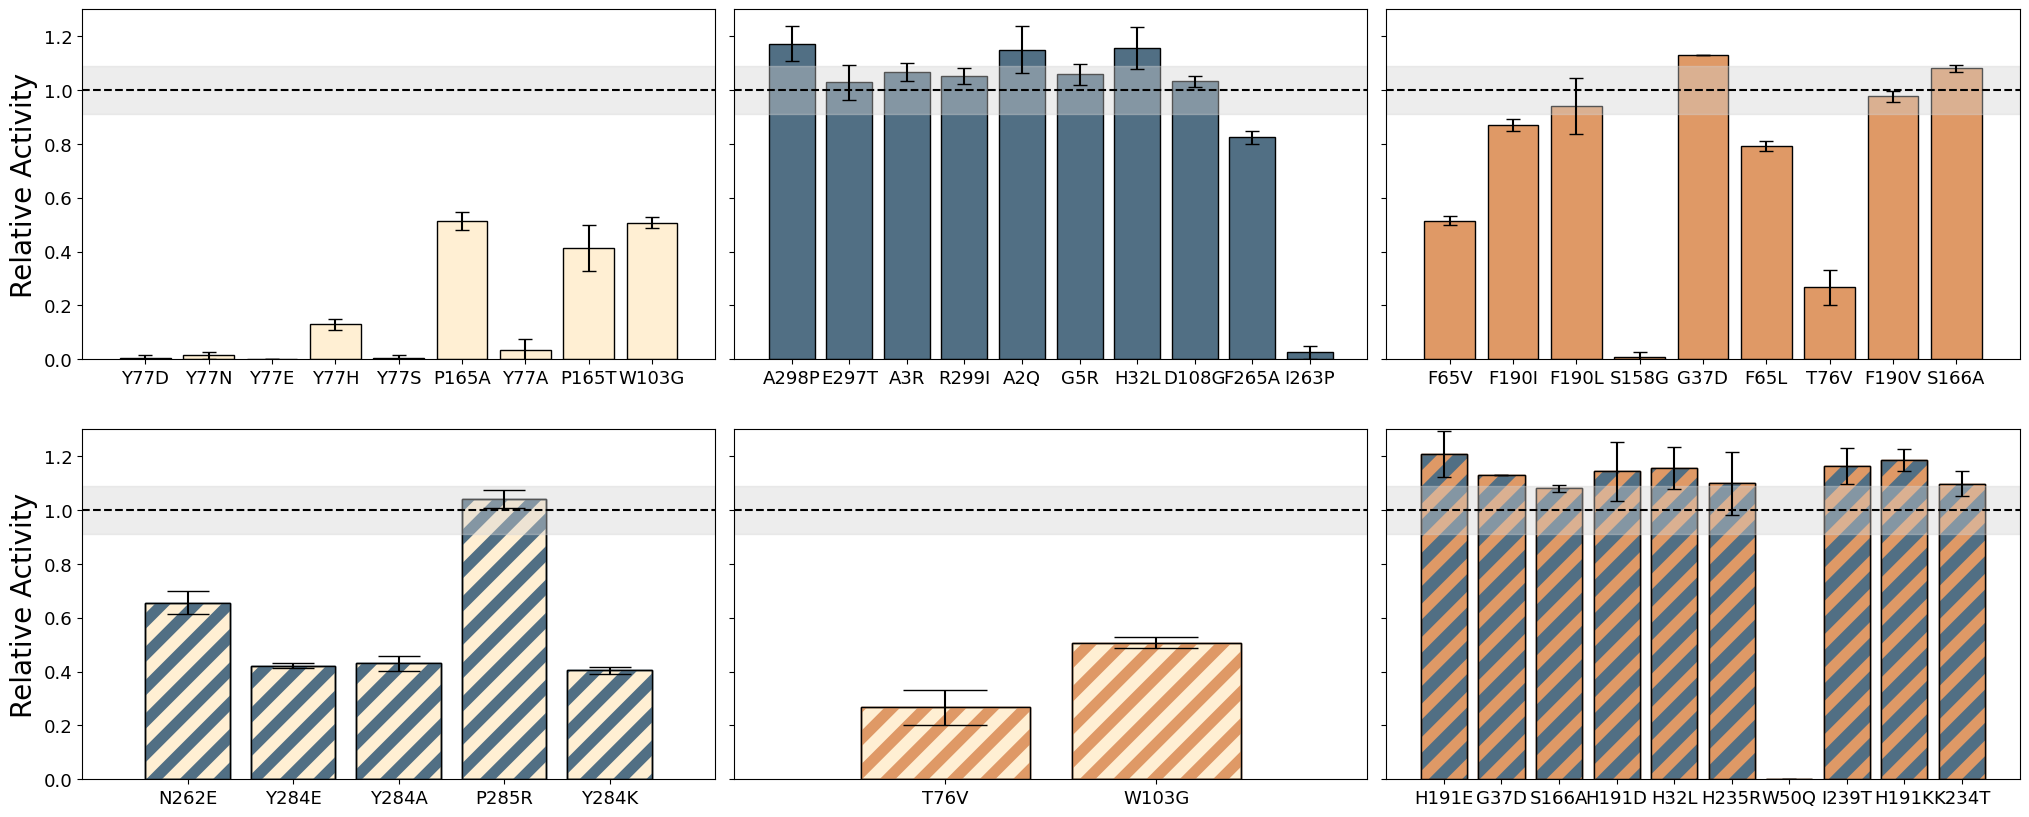

In [676]:
### Plotting - plot by model and protein

time = 2 ### Selected time, must be element of [2, 5, 180]
SAM = 300 ### Selected time, must be element of [10, 300]
capsizes = [5,5,5,15,30,5]
models=["ESM1b", "TranceptEVE", "ESM-IF1", "ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]

fig, axs=plt.subplots(2,3, figsize=(25,10),sharey=True, gridspec_kw={'wspace': 0.03,'hspace': 0.2})

axs=axs.flatten()

for i,model in enumerate(models[:3]):

    subset = relact_var_models.loc[relact_var_models[model] & (relact_var_models["Time(min)"] == time) & (relact_var_models["SAM_conc(uM)"] == SAM)]

    ### Restructure dataset and calculate mean & stddev per protein
    subset = pd.melt(subset, id_vars=["Protein", f"{model}_rank"], value_vars=["Relative_Activity"])
    plotdata = subset.groupby("Protein")["value"].agg(["mean", "std"]).reset_index()
    plotdata = plotdata.merge(subset[["Protein", f"{model}_rank"]], on="Protein", how="left").sort_values(f"{model}_rank").drop_duplicates().reset_index(drop=True)

    axs[i].bar(x=plotdata["Protein"], height=plotdata["mean"],yerr=plotdata["std"],color=model_color[model],
                edgecolor='black',capsize=capsizes[i])
    axs[i].axhline(y=1, color="black", linestyle = "--")
    axs[i].set_ylim(0,1.3)
    axs[i].tick_params(axis='both', which='major', labelsize=13)
    axs[i].fill_between([-1, len(plotdata["Protein"])], 1 - ref_2_std, 1 + ref_2_std, color='lightgrey', alpha=0.4)
    axs[i].set_ylim(0,1.3)
    axs[i].set_xlim(-1, len(plotdata["Protein"]))

for i,model in enumerate(models[3:]):

    subset = relact_var_models.loc[relact_var_models[model] & (relact_var_models["Time(min)"] == time) & (relact_var_models["SAM_conc(uM)"] == SAM)]

    ### Restructure dataset and calculate mean & stddev per protein
    subset = pd.melt(subset, id_vars=["Protein", f"{model}_rank"], value_vars=["Relative_Activity"])
    plotdata = subset.groupby("Protein")["value"].agg(["mean", "std"]).reset_index()
    plotdata = plotdata.merge(subset[["Protein", f"{model}_rank"]], on="Protein", how="left").sort_values(f"{model}_rank").drop_duplicates().reset_index(drop=True)
    
    axs[i+3].bar(x=plotdata["Protein"], height=plotdata["mean"],yerr=plotdata["std"],color=model_color[model.split("_")[0]],
                edgecolor='black',capsize=capsizes[i+3])
    axs[i+3].bar(x=plotdata["Protein"], height=plotdata["mean"],color='none',hatch='/',
                edgecolor=model_color[model.split("_")[1]])
    axs[i+3].bar(x=plotdata["Protein"], height=plotdata["mean"],color='none',
                edgecolor='k')
    axs[i+3].axhline(y=1, color="black", linestyle = "--")
    axs[i+3].set_ylim(0,1.3)
    axs[i+3].tick_params(axis='both', which='major', labelsize=13)
    axs[i+3].fill_between([-1, len(plotdata["Protein"])], 1 - ref_2_std, 1 + ref_2_std, color='lightgrey', alpha=0.4)
    axs[i+3].set_ylim(0,1.3)
    axs[i+3].set_xlim(-1, len(plotdata["Protein"]))

axs[0].set_ylabel("Relative Activity", fontsize=20)
axs[3].set_ylabel("Relative Activity", fontsize=20)

plt.subplots_adjust(hspace=0.5)
plt.show()

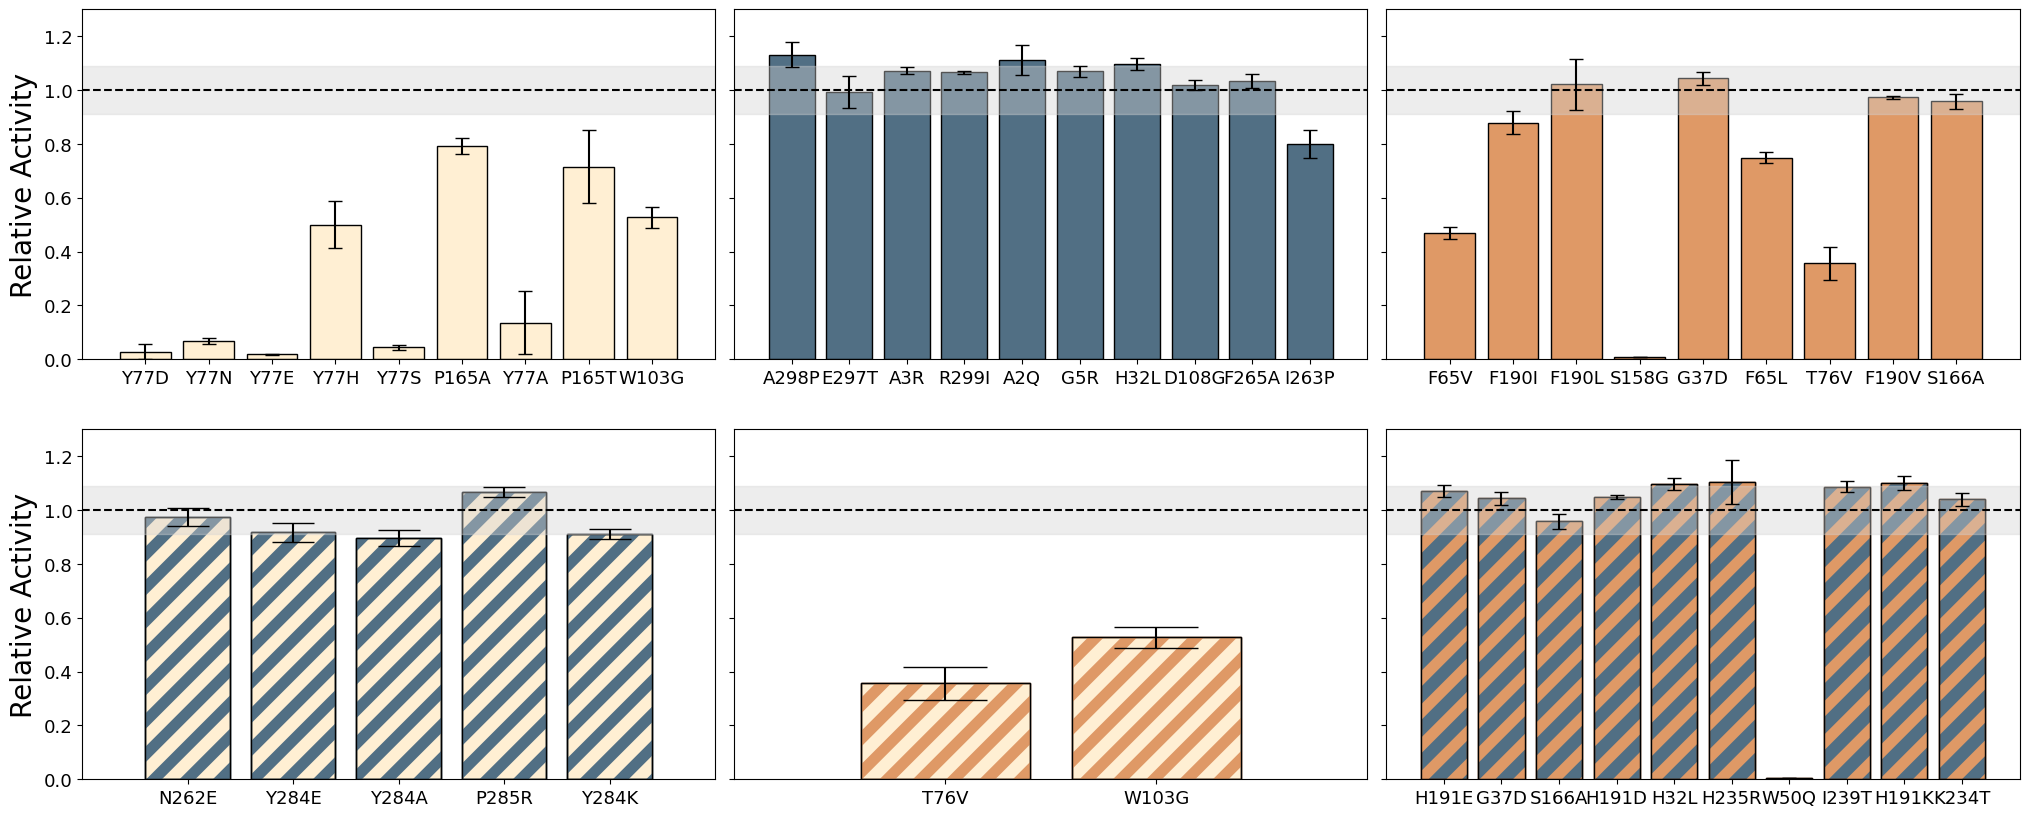

In [677]:
### Plotting - plot by model and protein

time = 180 ### Selected time, must be element of [2, 5, 180]
SAM = 300 ### Selected time, must be element of [10, 300]
capsizes = [5,5,5,15,30,5]
models=["ESM1b", "TranceptEVE", "ESM-IF1", "ESM1b_TranceptEVE", "ESM1b_ESM-IF1", "TranceptEVE_ESM-IF1"]

fig, axs=plt.subplots(2,3, figsize=(25,10),sharey=True, gridspec_kw={'wspace': 0.03,'hspace': 0.2})

axs=axs.flatten()

for i,model in enumerate(models[:3]):

    subset = relact_var_models.loc[relact_var_models[model] & (relact_var_models["Time(min)"] == time) & (relact_var_models["SAM_conc(uM)"] == SAM)]

    ### Restructure dataset and calculate mean & stddev per protein
    subset = pd.melt(subset, id_vars=["Protein", f"{model}_rank"], value_vars=["Relative_Activity"])
    plotdata = subset.groupby("Protein")["value"].agg(["mean", "std"]).reset_index()
    plotdata = plotdata.merge(subset[["Protein", f"{model}_rank"]], on="Protein", how="left").sort_values(f"{model}_rank").drop_duplicates().reset_index(drop=True)

    axs[i].bar(x=plotdata["Protein"], height=plotdata["mean"],yerr=plotdata["std"],color=model_color[model],
                edgecolor='black',capsize=capsizes[i])
    axs[i].axhline(y=1, color="black", linestyle = "--")
    axs[i].set_ylim(0,1.3)
    axs[i].tick_params(axis='both', which='major', labelsize=13)
    axs[i].fill_between([-1, len(plotdata["Protein"])], 1 - ref_2_std, 1 + ref_2_std, color='lightgrey', alpha=0.4)
    axs[i].set_ylim(0,1.3)
    axs[i].set_xlim(-1, len(plotdata["Protein"]))

for i,model in enumerate(models[3:]):

    subset = relact_var_models.loc[relact_var_models[model] & (relact_var_models["Time(min)"] == time) & (relact_var_models["SAM_conc(uM)"] == SAM)]

    ### Restructure dataset and calculate mean & stddev per protein
    subset = pd.melt(subset, id_vars=["Protein", f"{model}_rank"], value_vars=["Relative_Activity"])
    plotdata = subset.groupby("Protein")["value"].agg(["mean", "std"]).reset_index()
    plotdata = plotdata.merge(subset[["Protein", f"{model}_rank"]], on="Protein", how="left").sort_values(f"{model}_rank").drop_duplicates().reset_index(drop=True)
    
    axs[i+3].bar(x=plotdata["Protein"], height=plotdata["mean"],yerr=plotdata["std"],color=model_color[model.split("_")[0]],
                edgecolor='black',capsize=capsizes[i+3])
    axs[i+3].bar(x=plotdata["Protein"], height=plotdata["mean"],color='none',hatch='/',
                edgecolor=model_color[model.split("_")[1]])
    axs[i+3].bar(x=plotdata["Protein"], height=plotdata["mean"],color='none',
                edgecolor='k')
    axs[i+3].axhline(y=1, color="black", linestyle = "--")
    axs[i+3].fill_between([-1, len(plotdata["Protein"])], 1 - ref_2_std, 1 + ref_2_std, color='lightgrey', alpha=0.4)
    axs[i+3].set_ylim(0,1.3)
    axs[i+3].set_xlim(-1, len(plotdata["Protein"]))
    axs[i+3].tick_params(axis='both', which='major', labelsize=13)

axs[0].set_ylabel("Relative Activity", fontsize=20)
axs[3].set_ylabel("Relative Activity", fontsize=20)

plt.subplots_adjust(hspace=0.5)
plt.show()

In [678]:
FlA_HIM_ESM1b=pd.read_csv('../results/ESM1b/FlA_HIM_RelAct.csv')
FlA_HIM_TranceptEVE=pd.read_csv('../results/TranceptEVE/TranceptEVE_M/FlA_HIM_RelAct.csv')
FlA_HIM_ESM_IF1=pd.read_csv('../results/ESM-IF1/FlA_HIM_RelAct.csv')
FlA_HIM_merge = pd.merge(FlA_HIM_ESM1b,FlA_HIM_TranceptEVE[['mutant','avg_score']], on='mutant',suffixes=('_ESM1b','_TranceptEVE'))
FlA_HIM_merge = pd.merge(FlA_HIM_merge,FlA_HIM_ESM_IF1[['mutant','esmif1_ll']], on='mutant')

In [679]:
t = 2
SAM = 300
subset = relact_var_models[(relact_var_models["Time(min)"] == t) & (relact_var_models["SAM_conc(uM)"] == SAM)]
subset = subset[['Protein','Relative_Activity','ESM1b_score','TranceptEVE_score','ESM-IF1_score','ESM1b','TranceptEVE','ESM-IF1','ESM1b_TranceptEVE','ESM1b_ESM-IF1','TranceptEVE_ESM-IF1']]

# Compute mean and std for "Relative_Activity"
df_stats = subset.groupby("Protein", as_index=False).agg(
    Relative_Activity_mean=("Relative_Activity", "mean"),
    Relative_Activity_std=("Relative_Activity", "std")
)

# Merge with a representative row from the original dataset to keep other columns
df_other = subset.groupby("Protein").first().reset_index()

# Merge back with mean and std values
df_final = df_other.merge(df_stats, on="Protein").drop('Relative_Activity', axis=1)
df_ESM1b=df_final[df_final['ESM1b']+df_final['ESM1b_TranceptEVE']+df_final['ESM1b_ESM-IF1']]
df_TranceptEVE=df_final[df_final['TranceptEVE']+df_final['ESM1b_TranceptEVE']+df_final['TranceptEVE_ESM-IF1']]
df_ESM_IF1=df_final[df_final['ESM-IF1']+df_final['ESM1b_ESM-IF1']+df_final['TranceptEVE_ESM-IF1']]

In [680]:
t = 180
SAM = 300
subset = relact_var_models[(relact_var_models["Time(min)"] == t) & (relact_var_models["SAM_conc(uM)"] == SAM)]
subset = subset[['Protein','Relative_Activity','ESM1b_score','TranceptEVE_score','ESM-IF1_score','ESM1b','TranceptEVE','ESM-IF1','ESM1b_TranceptEVE','ESM1b_ESM-IF1','TranceptEVE_ESM-IF1']]

# Compute mean and std for "Relative_Activity"
df_stats = subset.groupby("Protein", as_index=False).agg(
    Relative_Activity_mean=("Relative_Activity", "mean"),
    Relative_Activity_std=("Relative_Activity", "std")
)

# Merge with a representative row from the original dataset to keep other columns
df_other = subset.groupby("Protein").first().reset_index()

# Merge back with mean and std values
df_final = df_other.merge(df_stats, on="Protein").drop('Relative_Activity', axis=1)
df_ESM1b=df_final[df_final['ESM1b']+df_final['ESM1b_TranceptEVE']+df_final['ESM1b_ESM-IF1']]
df_TranceptEVE=df_final[df_final['TranceptEVE']+df_final['ESM1b_TranceptEVE']+df_final['TranceptEVE_ESM-IF1']]
df_ESM_IF1=df_final[df_final['ESM-IF1']+df_final['ESM1b_ESM-IF1']+df_final['TranceptEVE_ESM-IF1']]

## Combinatorial Mutants

In [681]:
### Multi Mutants

# Get csv file 
relact = pd.read_csv("data/FlA_ZP_comb.csv", sep=";")
relact['FDA_conc'] = FDA_number*(relact['FDA Area'])
relact['SAM_conc'] = SAM_number*(relact['SAM DG Area'])
relact["%SAM_converted"] = relact['FDA_conc'] / (relact['FDA_conc'] + relact['SAM_conc']) * 100



# Filter for the reference condition (Protein == "WT")
reference = relact[relact["Protein"] == "WT"]

# Merge the reference values back into the original DataFrame based on the same condition
relact = relact.merge(
    reference[["Plate", "Time(min)", "SAM_conc(uM)", "Replicate", "%SAM_converted"]],
    on=["Plate", "Time(min)", "SAM_conc(uM)", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# # Calculate Relative_Activity
# relact["Relative_Activity"] = relact["%SAM_converted"] / relact["%SAM_converted_ref"]

# # Drop the intermediate reference column 
# relact.drop(columns=["%SAM_converted_ref"], inplace=True)


# relact_var = relact.drop(relact.index[relact["Protein"] == "WT"].tolist())
# # print(relact_var)
relact = relact.drop(relact.index[relact["Plate"] == "ZP-double_2"].tolist()).reset_index(drop=True)
# print(relact_var)

In [682]:
relact

,Sample ID,Plate,Protein,Time(min),SAM_conc(uM),Replicate,Inj. Volume,Dilution,FDA Area,SAM DG Area,FDA Corr.,SAM Corr.,%SAM_converted,FDA_conc,SAM_conc,%SAM_converted_ref
0,WT_2min_300uM_1,ZP-double_2_repeat,WT,2,300,1,40,2,0.6189,45.8608,0.30945,22.93040,0.397868,1.923541,481.53840,0.397868
1,S166A-H191E_2min_300uM_1,ZP-double_2_repeat,S166A-H191E,2,300,1,40,2,0.6250,45.2780,0.31250,22.63900,0.406924,1.942500,475.41900,0.397868
2,S166A-G37D_2min_300uM_1,ZP-double_2_repeat,S166A-G37D,2,300,1,40,2,0.5544,42.6453,0.27720,21.32265,0.383333,1.723075,447.77565,0.397868
3,S166A-H32L_2min_300uM_1,ZP-double_2_repeat,S166A-H32L,2,300,1,40,2,0.6080,46.2365,0.30400,23.11825,0.387724,1.889664,485.48325,0.397868
4,H191E-G37D_2min_300uM_1,ZP-double_2_repeat,H191E-G37D,2,300,1,40,2,0.6531,49.5113,0.32655,24.75565,0.388933,2.029835,519.86865,0.397868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,H32L-G37D-H191E_3h_10uM_3,ZP_Comb_Rep_2,H32L-G37D-H191E,180,10,3,20,2,0.8007,0.3450,0.80070,0.34500,40.722383,2.488576,3.62250,40.694548
406,H32L-S166A-H191E_3h_10uM_3,ZP_Comb_Rep_2,H32L-S166A-H191E,180,10,3,20,2,0.8020,0.3451,0.80200,0.34510,40.754551,2.492616,3.62355,40.694548
407,G37D-S166A-H191E_3h_10uM_3,ZP_Comb_Rep_2,G37D-S166A-H191E,180,10,3,20,2,0.3911,0.1701,0.39110,0.17010,40.496513,1.215539,1.78605,40.694548
408,H32L-G37D-S166A-H191E_3h_10uM_3,ZP_Comb_Rep_2,H32L-G37D-S166A-H191E,180,10,3,20,2,0.6752,0.2886,0.67520,0.28860,40.916253,2.098522,3.03030,40.694548


In [683]:
SAM = 300
t = 2
subset_2_comb = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

t = 180
subset_180_comb = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

ref_2 = subset_2_comb[subset_2_comb["Protein"] == "WT"]
wt_conv_2 = ref_2['%SAM_converted'].values
wt_mean_2 = np.mean(wt_conv_2)

subset_2_comb['Relative_Activity'] = subset_2_comb['%SAM_converted'] / wt_mean_2

ref_180 = subset_180_comb[subset_180_comb["Protein"] == "WT"]
wt_conv_180 = ref_180['%SAM_converted'].values
wt_mean_180 = np.mean(wt_conv_180)

subset_180_comb['Relative_Activity'] = subset_180_comb['%SAM_converted'] / wt_mean_180

relact['Relative_Activity'] = [subset_2_comb['Relative_Activity'][i] if (relact['Time(min)'][i]==2 and relact['SAM_conc(uM)'][i]==300) else subset_180_comb['Relative_Activity'][i] if (relact['Time(min)'][i]==180 and relact['SAM_conc(uM)'][i]==300) else np.nan for i in range(len(relact))]

ref_2 = relact[(relact["Protein"] == "WT") & (relact["Time(min)"] == 2) & (relact["SAM_conc(uM)"] == SAM)]
ref_2_std = ref_2['Relative_Activity'].std()
ref_180 = relact[(relact["Protein"] == "WT") & (relact["Time(min)"] == 180) & (relact["SAM_conc(uM)"] == SAM)]
ref_180_std = ref_180['Relative_Activity'].std()

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/1637855349.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2_comb['Relative_Activity'] = subset_2_comb['%SAM_converted'] / wt_mean_2
/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/1637855349.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_180_comb['Relative_Activity'] = subset_180_comb['%SAM_converted'] / wt_mean_180


In [684]:
t = 2
sam = 300
subset = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == sam)]
mm_act_2_replicate = []
for prot in pd.unique(subset.Protein):
    if prot == 'Ctrl' or prot == 'N4V' or prot == 'WT':
        continue

    subset_ = subset.loc[subset.Protein == prot]
    for rep in pd.unique(subset_.Replicate):
        act_ = subset_[subset_.Replicate == rep].Relative_Activity.values[-1]
        mm_act_2_replicate.append([prot,act_,rep])
mm_act_2_replicate = pd.DataFrame(mm_act_2_replicate, columns=["Protein", "Relative_Activity", "Replicate"])

t = 180
sam = 300
subset = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == sam)]
mm_act_180_replicate = []
for prot in pd.unique(subset.Protein):
    if prot == 'Ctrl' or prot == 'N4V' or prot == 'WT':
        continue

    subset_ = subset.loc[subset.Protein == prot]
    for rep in pd.unique(subset_.Replicate):
        act_ = subset_[subset_.Replicate == rep].Relative_Activity.values[-1]
        mm_act_180_replicate.append([prot,act_,rep])
mm_act_180_replicate = pd.DataFrame(mm_act_180_replicate, columns=["Protein", "Relative_Activity", "Replicate"])

In [685]:
#Set timepoint and SAM conc.
t=2 # [2,5,180]
SAM=300 # [10,300]

subset_2_multi = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]# & (relact['Inj. Volume']==20)]
unique_prot = pd.unique(subset_2_multi.Protein[(subset_2_multi.Protein!= "Ctrl")&(subset_2_multi.Protein!= "N4V")&(subset_2_multi.Protein!= "WT")])
subset_2_multi = pd.concat([subset_2_multi.loc[subset_2_multi["Protein"] == prot].iloc[-3:] for prot in unique_prot])

subset_2_multi_mean = [subset_2_multi.loc[subset_2_multi["Protein"] == prot, "Relative_Activity"].mean() for prot in unique_prot]
subset_2_multi_std = [subset_2_multi.loc[subset_2_multi["Protein"] == prot, "Relative_Activity"].std() for prot in unique_prot]
subset_2_multi_pd = pd.DataFrame(
    {
        "Protein": unique_prot,
        "Relative_Activity_mean": subset_2_multi_mean,
        "Relative_Activity_std": subset_2_multi_std
    }
)

subset_2_multi_pd['Mut_count'] = subset_2_multi_pd["Protein"].str.count("-") + 1
subset_2_multi_pd = subset_2_multi_pd.sort_values(by="Mut_count", ascending=True).reset_index(drop=True)

#Set timepoint and SAM conc.
t=180 # [2,5,180]
SAM=300 # [10,300]

subset_180_multi = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]# & (relact_var['Inj. Volume']==20)]
unique_prot = pd.unique(subset_180_multi.Protein[(subset_180_multi.Protein!= "Ctrl")&(subset_180_multi.Protein!= "N4V")&(subset_180_multi.Protein!= "WT")])
subset_180_multi = pd.concat([subset_180_multi.loc[subset_180_multi["Protein"] == prot].iloc[-3:] for prot in unique_prot])


subset_180_multi_mean = [subset_180_multi.loc[subset_180_multi["Protein"] == prot, "Relative_Activity"].mean() for prot in unique_prot]
subset_180_multi_std = [subset_180_multi.loc[subset_180_multi["Protein"] == prot, "Relative_Activity"].std() for prot in unique_prot]
subset_180_multi_pd = pd.DataFrame(
    {
        "Protein": unique_prot,
        "Relative_Activity_mean": subset_180_multi_mean,
        "Relative_Activity_std": subset_180_multi_std
    }
)

subset_180_multi_pd['Mut_count'] = subset_180_multi_pd["Protein"].str.count("-") + 1
subset_180_multi_pd = subset_180_multi_pd.sort_values(by="Mut_count", ascending=True).reset_index(drop=True)

In [686]:
subset_2_multi = subset_2_multi[(~subset_2_multi.Protein.isin(['N4V','Ctrl','WT']))]
subset_2_multi['Mut_count'] = subset_2_multi.Protein.str.count('-') +1

In [687]:
results = []
sig_threshold = 0.05
for name, group in mm_act_2_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_2.Relative_Activity.values)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

mm_act_2_res_df = pd.DataFrame(results)

results = []
sig_threshold = 0.05
for name, group in mm_act_2_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_2.Relative_Activity.values)
    
    # One-sided test (mutant < WT)
    if t_stat < 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

mm_act_2_neg_res_df = pd.DataFrame(results)

results = []
for name, group in mm_act_180_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_180.Relative_Activity.values)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

mm_act_180_res_df = pd.DataFrame(results)

(-0.5, 10.5)

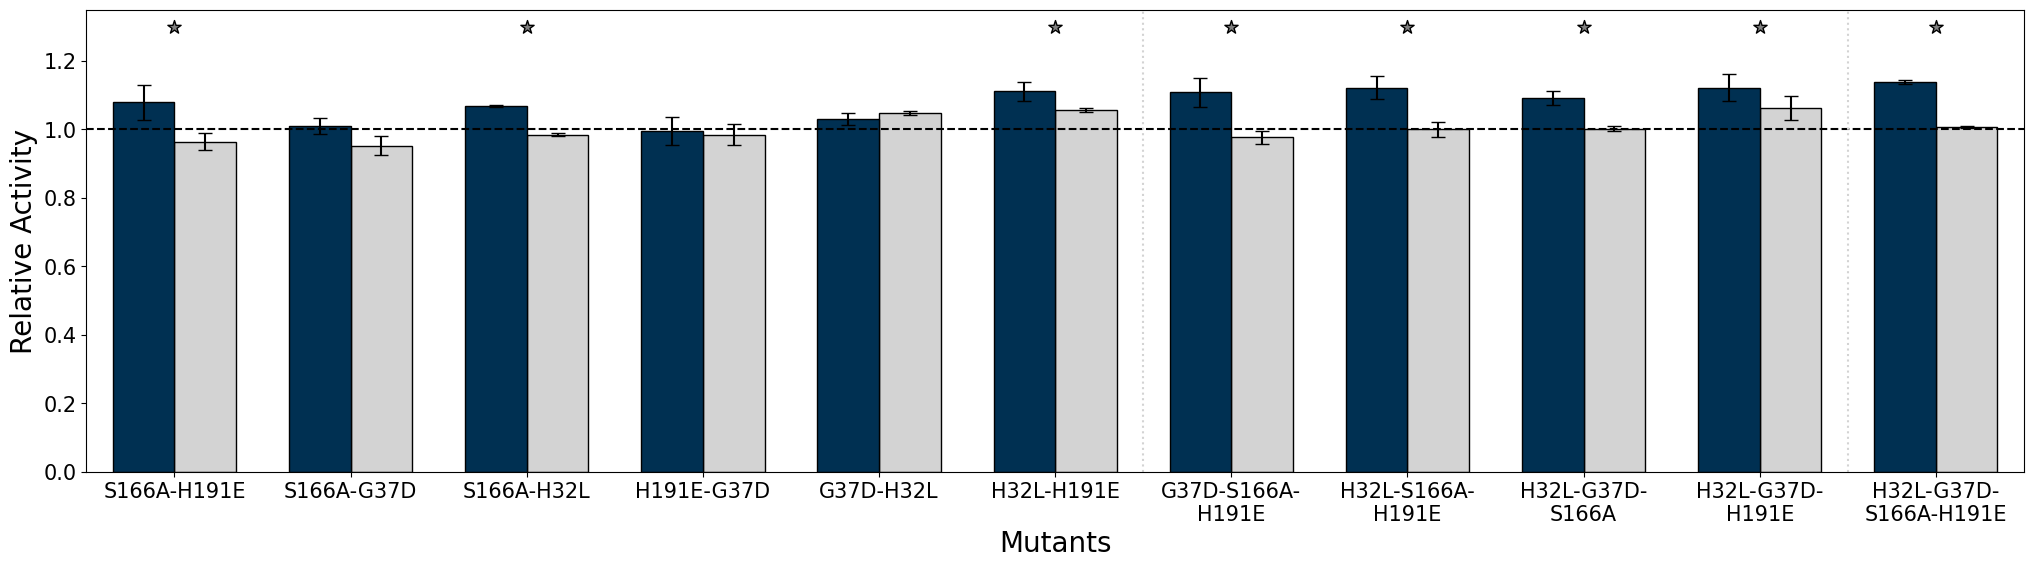

In [688]:
color_ = ['lightgrey','#003052']

fig, ax= plt.subplots(figsize=(25,6))
width = 0.35
x_2 = np.arange(len(subset_2_multi_pd.Protein))-(width/2)
x_180 = np.arange(len(subset_180_multi_pd.Protein))+(width/2)
ax.bar(x_180,subset_180_multi_pd.Relative_Activity_mean, yerr=subset_180_multi_pd.Relative_Activity_std,
        capsize=5, edgecolor='black', color=color_[0],width=width)
ax.bar(x_2,subset_2_multi_pd.Relative_Activity_mean, yerr=subset_2_multi_pd.Relative_Activity_std,
        capsize=5, edgecolor='black', color=color_[1],width=width)

ax.set_xticks(np.arange(len(subset_2_multi_pd.Protein)))
ax.set_xticklabels(['S166A-H191E',
 'S166A-G37D',
 'S166A-H32L',
 'H191E-G37D',
 'G37D-H32L',
 'H32L-H191E',
 'G37D-S166A-\nH191E',
 'H32L-S166A-\nH191E',
 'H32L-G37D-\nS166A',
 'H32L-G37D-\nH191E',
 'H32L-G37D-\nS166A-H191E',
 ], rotation=0, ha='center')

for i, mut in enumerate(subset_2_multi_pd.Protein):
        if mm_act_2_res_df.loc[mm_act_2_res_df.Mutant == mut, "Significant"].values[0]:
            ax.scatter(i, 1.3, color='grey', s=100, edgecolor='black', marker='*', zorder=3)

        if mm_act_2_neg_res_df.loc[mm_act_2_neg_res_df.Mutant == mut, "Significant"].values[0]:
                ax.scatter(i, 1.3, color='red', s=100, edgecolor='black', marker='x', zorder=3)
ax.axhline(y=1, color='black', linestyle='--')
#ax.fill_between([-1, len(subset_2_multi_pd.Protein)], 1 - ref_2_std, 1 + ref_2_std, color='lightgrey', alpha=0.4)

    
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel("Mutants", fontsize=20)

for x_ in [5.5,9.5]:
        ax.axvline(x=x_, color='lightgray', linestyle=':')
        
ax.set_ylabel("Relative Activity", fontsize=20)
ax.set_ylim(0, 1.35)
ax.set_xlim(-0.5, len(subset_2_multi_pd.Protein)-0.5)

Text(0, 0.5, 'Relative Activity')

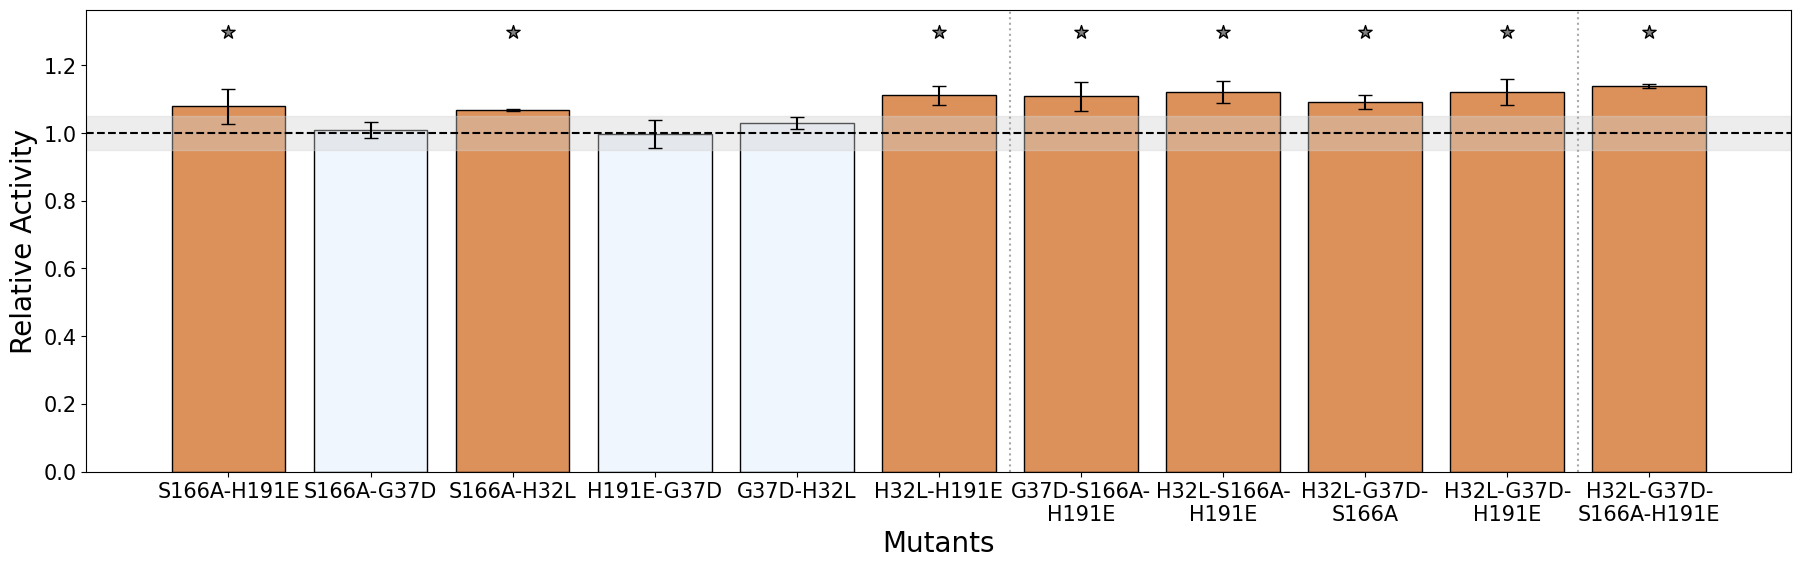

In [706]:
sig_colors = {'WT-like': '#F0F6FD',
              'Pos':'#DC915A',
              'Neg':'#4C5E69',}

fig, ax= plt.subplots(figsize=(22,6))
width = 0.8
for i,prot in enumerate(subset_2_multi_pd.Protein):
    #color = target_colors[variant_cat[prot]]
    sig_ = 'Pos' if mm_act_2_res_df.loc[mm_act_2_res_df.Mutant == prot, "Significant"].values[0] else 'Neg' if mm_act_2_neg_res_df.loc[mm_act_2_neg_res_df.Mutant == prot, "Significant"].values[0] else 'WT-like'
    color = sig_colors[sig_]
    x = prot
    ax.bar(x, subset_2_multi_pd.Relative_Activity_mean[i], yerr=subset_2_multi_pd.Relative_Activity_std[i],
        capsize=5, edgecolor='black', color=color, width=width)
    
    if sig_ == 'Pos':
        ax.scatter(i, 1.3, color='grey', s=100, edgecolor='black', marker='*', zorder=3)
    #elif sig_ == 'Neg':
    #    ax.scatter(i, 1.3, color='red', s=100, edgecolor='black', marker='x', zorder=3)
    
ax.set_xticks(np.arange(len(subset_2_multi_pd.Protein)))
ax.set_xticklabels(['S166A-H191E',
 'S166A-G37D',
 'S166A-H32L',
 'H191E-G37D',
 'G37D-H32L',
 'H32L-H191E',
 'G37D-S166A-\nH191E',
 'H32L-S166A-\nH191E',
 'H32L-G37D-\nS166A',
 'H32L-G37D-\nH191E',
 'H32L-G37D-\nS166A-H191E',
 ], rotation=0, ha='center')

ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel("Mutants", fontsize=20)

for x_ in [5.5,9.5]:
        ax.axvline(x=x_, color='darkgray', linestyle=':')

ax.axhline(y=1, color='black', linestyle='--')
ax.fill_between([-1, len(subset_2_multi_pd.Protein)], 1 - ref_2_std, 1 + ref_2_std, color='lightgrey', alpha=0.4)
ax.set_xlim(-1, len(subset_2_multi_pd.Protein))
        
ax.set_ylabel("Relative Activity", fontsize=20)

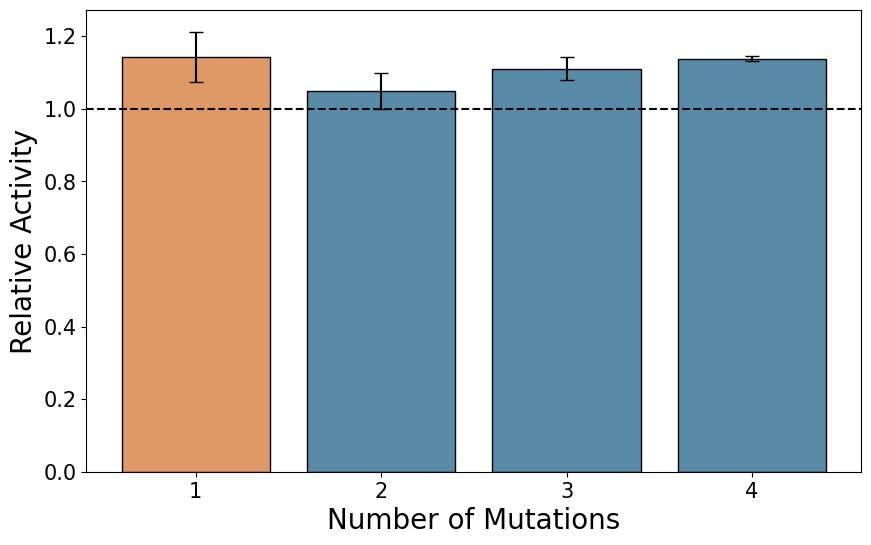

In [690]:
fig, ax= plt.subplots(figsize=(10,6))
x_ = np.arange(4)
ax.bar(x_, [subset_2[subset_2.Protein.isin(['H191E','H32L','G37D','S166A'])].Relative_Activity.mean(),subset_2_multi[subset_2_multi.Mut_count == 2].Relative_Activity.mean(),
          subset_2_multi[subset_2_multi.Mut_count == 3].Relative_Activity.mean(),
          subset_2_multi[subset_2_multi.Mut_count == 4].Relative_Activity.mean()],
       yerr=[subset_2[subset_2.Protein.isin(['H191E','H32L','G37D','S166A'])].Relative_Activity.std(),subset_2_multi[subset_2_multi.Mut_count == 2].Relative_Activity.std(),
          subset_2_multi[subset_2_multi.Mut_count == 3].Relative_Activity.std(),
          subset_2_multi[subset_2_multi.Mut_count == 4].Relative_Activity.std()],
          capsize=5, edgecolor='black', color=['#DF9966',"#588BA8","#588BA8","#588BA8"])
ax.set_xticks(x_)
ax.set_xticklabels(['1', '2', '3', '4'], rotation=0, ha='center')

ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel("Number of Mutations", fontsize=20)
ax.set_ylabel("Relative Activity", fontsize=20)

ax.axhline(y=1, color='black', linestyle='--')

## Targeted Engineering

In [691]:
relact

,Sample ID,Plate,Protein,Time(min),SAM_conc(uM),Replicate,Inj. Volume,Dilution,FDA Area,SAM DG Area,FDA Corr.,SAM Corr.,%SAM_converted,FDA_conc,SAM_conc,%SAM_converted_ref,Relative_Activity
0,WT_2min_300uM_1,ZP-double_2_repeat,WT,2,300,1,40,2,0.6189,45.8608,0.30945,22.93040,0.397868,1.923541,481.53840,0.397868,0.941995
1,S166A-H191E_2min_300uM_1,ZP-double_2_repeat,S166A-H191E,2,300,1,40,2,0.6250,45.2780,0.31250,22.63900,0.406924,1.942500,475.41900,0.397868,0.963436
2,S166A-G37D_2min_300uM_1,ZP-double_2_repeat,S166A-G37D,2,300,1,40,2,0.5544,42.6453,0.27720,21.32265,0.383333,1.723075,447.77565,0.397868,0.907580
3,S166A-H32L_2min_300uM_1,ZP-double_2_repeat,S166A-H32L,2,300,1,40,2,0.6080,46.2365,0.30400,23.11825,0.387724,1.889664,485.48325,0.397868,0.917979
4,H191E-G37D_2min_300uM_1,ZP-double_2_repeat,H191E-G37D,2,300,1,40,2,0.6531,49.5113,0.32655,24.75565,0.388933,2.029835,519.86865,0.397868,0.920840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,H32L-G37D-H191E_3h_10uM_3,ZP_Comb_Rep_2,H32L-G37D-H191E,180,10,3,20,2,0.8007,0.3450,0.80070,0.34500,40.722383,2.488576,3.62250,40.694548,NaN
406,H32L-S166A-H191E_3h_10uM_3,ZP_Comb_Rep_2,H32L-S166A-H191E,180,10,3,20,2,0.8020,0.3451,0.80200,0.34510,40.754551,2.492616,3.62355,40.694548,NaN
407,G37D-S166A-H191E_3h_10uM_3,ZP_Comb_Rep_2,G37D-S166A-H191E,180,10,3,20,2,0.3911,0.1701,0.39110,0.17010,40.496513,1.215539,1.78605,40.694548,NaN
408,H32L-G37D-S166A-H191E_3h_10uM_3,ZP_Comb_Rep_2,H32L-G37D-S166A-H191E,180,10,3,20,2,0.6752,0.2886,0.67520,0.28860,40.916253,2.098522,3.03030,40.694548,NaN


In [692]:
### Rational Engineered Mutants

# Get csv file 
relact = pd.read_csv("data/FlA_ZP_RatEng.csv", sep=";")
relact['FDA_conc'] = FDA_number*(relact['FDA Area'])
relact['SAM_conc'] = SAM_number*(relact['SAM DG Area'])
relact["%SAM_converted"] = relact['FDA_conc'] / (relact['FDA_conc'] + relact['SAM_conc']) * 100


# Filter for the reference condition (Protein == "WT")
reference = relact[relact["Protein"] == "WT"]

# Merge the reference values back into the original DataFrame based on the same condition
relact = relact.merge(
    reference[["Plate", "Time(min)", "SAM_conc(uM)", "Replicate", "%SAM_converted"]],
    on=["Plate", "Time(min)", "SAM_conc(uM)", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# # Calculate Relative_Activity
# relact["Relative_Activity"] = relact["%SAM_converted"] / relact["%SAM_converted_ref"]

# # Drop the intermediate reference column 
# relact.drop(columns=["%SAM_converted_ref"], inplace=True)


# relact_var = relact.drop(relact.index[relact["Protein"] == "WT"].tolist())
# print(relact_var)
relact = relact.drop(relact.index[relact["Plate"] == "ZP-double_2"].tolist())
# print(relact_var)

In [693]:
SAM = 300
t = 2
subset_2_comb = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

t = 180
subset_180_comb = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]

ref_2 = subset_2_comb[subset_2_comb["Protein"] == "WT"]
wt_conv_2 = ref_2["%SAM_converted"].values
wt_mean_2 = np.mean(wt_conv_2)

subset_2_comb['Relative_Activity'] = subset_2_comb['%SAM_converted'] / wt_mean_2

ref_180 = subset_180_comb[subset_180_comb["Protein"] == "WT"]
wt_conv_180 = ref_180['%SAM_converted'].values
wt_mean_180 = np.mean(wt_conv_180)

subset_180_comb['Relative_Activity'] = subset_180_comb['%SAM_converted'] / wt_mean_180

relact['Relative_Activity'] = [subset_2_comb['Relative_Activity'][i] if (relact['Time(min)'][i]==2 and relact['SAM_conc(uM)'][i]==300) else subset_180_comb['Relative_Activity'][i] if (relact['Time(min)'][i]==180 and relact['SAM_conc(uM)'][i]==300) else np.nan for i in range(len(relact))]

ref_2 = relact[(relact["Protein"] == "WT") & (relact["Time(min)"] == 2) & (relact["SAM_conc(uM)"] == SAM)]
ref_2_std = ref_2['Relative_Activity'].std()
ref_180 = relact[(relact["Protein"] == "WT") & (relact["Time(min)"] == 180) & (relact["SAM_conc(uM)"] == SAM)]
ref_180_std = ref_180['Relative_Activity'].std()

/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/2175003775.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2_comb['Relative_Activity'] = subset_2_comb['%SAM_converted'] / wt_mean_2
/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_15214/2175003775.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_180_comb['Relative_Activity'] = subset_180_comb['%SAM_converted'] / wt_mean_180


In [694]:
unique_prot = pd.unique(relact.Protein[(relact.Protein!= "Ctrl")&(relact.Protein!= "N4V")&(relact.Protein!= "WT")])
unique_prot

array(['I120V', 'Q26I', 'S106A', 'F110E', 'F110I', 'Q232Y', 'K237R'],
      dtype=object)

In [695]:
pd.unique(relact.Protein)

array(['WT', 'I120V', 'N4V', 'Ctrl', 'Q26I', 'S106A', 'F110E', 'F110I',
       'Q232Y', 'K237R'], dtype=object)

In [696]:
t = 2
sam = 300
subset = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == sam)]
for prot in unique_prot:
    print(prot)
    print(subset.loc[subset["Protein"] == prot].shape[0])

I120V
3
Q26I
3
S106A
3
F110E
3
F110I
3
Q232Y
3
K237R
3


In [697]:
t = 2
sam = 300
subset = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == sam)]
rat_act_2_replicate = []
for prot in pd.unique(subset.Protein):
    if prot == 'Ctrl' or prot == 'N4V' or prot == 'WT':
        continue

    subset_ = subset.loc[subset.Protein == prot]
    for rep in pd.unique(subset_.Replicate):
        act_ = subset_[subset_.Replicate == rep].Relative_Activity.values[0]
        rat_act_2_replicate.append([prot,act_,rep])
rat_act_2_replicate = pd.DataFrame(rat_act_2_replicate, columns=["Protein", "Relative_Activity", "Replicate"])

t = 180
sam = 300
subset = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == sam)]
rat_act_180_replicate = []
for prot in pd.unique(subset.Protein):
    if prot == 'Ctrl' or prot == 'N4V' or prot == 'WT':
        continue

    subset_ = subset.loc[subset.Protein == prot]
    for rep in pd.unique(subset_.Replicate):
        act_ = subset_[subset_.Replicate == rep].Relative_Activity.values[0]
        rat_act_180_replicate.append([prot,act_,rep])
rat_act_180_replicate = pd.DataFrame(rat_act_180_replicate, columns=["Protein", "Relative_Activity", "Replicate"])

In [698]:
results = []
sig_threshold = 0.05
for name, group in rat_act_2_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_2.Relative_Activity.values)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

rat_act_2_res_df = pd.DataFrame(results)

results = []
sig_threshold = 0.05
for name, group in rat_act_2_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_2.Relative_Activity.values)
    
    # One-sided test (mutant < WT)
    if t_stat < 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

rat_act_2_neg_res_df = pd.DataFrame(results)

results = []
for name, group in rat_act_180_replicate.groupby("Protein"):
    rel_activities = group["Relative_Activity"].values
    t_stat, p_val = ttest_ind(rel_activities, ref_2.Relative_Activity.values)
    
    # One-sided test (mutant > WT)
    if t_stat > 0:
        p_val = p_val / 2
    else:
        p_val = 1.0  # not better

    #Test hypothesis
    if p_val < sig_threshold:
        significant = True
    else:
        significant = False
    results.append({
        "Mutant": name,
        "t_stat": t_stat,
        "p_val_one_sided": p_val,
        "Significant": significant,

    })

rat_act_180_res_df = pd.DataFrame(results)

In [699]:
#Set timepoint and SAM conc.
t=2 # [2,5,180]
SAM=300 # [10,300]

subset_2_rateng = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]
unique_prot = pd.unique(subset_2_rateng.Protein[(subset_2_rateng.Protein!= "Ctrl")&(subset_2_rateng.Protein!= "N4V")&(subset_2_rateng.Protein!= "WT")])

subset_2_rateng_mean = [subset_2_rateng.loc[subset_2_rateng["Protein"] == prot, "Relative_Activity"].mean() for prot in unique_prot]
subset_2_rateng_std = [subset_2_rateng.loc[subset_2_rateng["Protein"] == prot, "Relative_Activity"].std() for prot in unique_prot]
subset_2_rateng_pd = pd.DataFrame(
    {
        "Protein": unique_prot,
        "Relative_Activity_mean": subset_2_rateng_mean,
        "Relative_Activity_std": subset_2_rateng_std
    }
)

#Set timepoint and SAM conc.
t=180 # [2,5,180]
SAM=300 # [10,300]

subset_180_rateng = relact.loc[(relact["Time(min)"] == t) & (relact["SAM_conc(uM)"] == SAM)]
unique_prot = pd.unique(subset_180_rateng.Protein[(subset_180_rateng.Protein!= "Ctrl")&(subset_180_rateng.Protein!= "N4V")&(subset_180_rateng.Protein!= "WT")])
subset_180_rateng_mean = [subset_180_rateng.loc[subset_180_rateng["Protein"] == prot, "Relative_Activity"].mean() for prot in unique_prot]
subset_180_rateng_std = [subset_180_rateng.loc[subset_180_rateng["Protein"] == prot, "Relative_Activity"].std() for prot in unique_prot]
subset_180_rateng_pd = pd.DataFrame(
    {
        "Protein": unique_prot,
        "Relative_Activity_mean": subset_180_rateng_mean,
        "Relative_Activity_std": subset_180_rateng_std
    }
)

In [700]:
target_colors = {'Nterm': '#FFEFD3',
    'AS': '#516F84',
    'Hexa': '#DF9966'}

sig_colors = {'WT-like': '#F0F6FD',
              'Pos':'#DC915A',
              'Neg':'#4C5E69',}

variant_cat = {'I120V': 'Nterm',
               'Q26I': 'AS',
               'S106A': 'AS',
               'F110E': 'AS',
               'F110I': 'AS',
               'Q232Y': 'Hexa',
               'K237R': 'Hexa',}

Text(0, 0.5, 'Relative Activity')

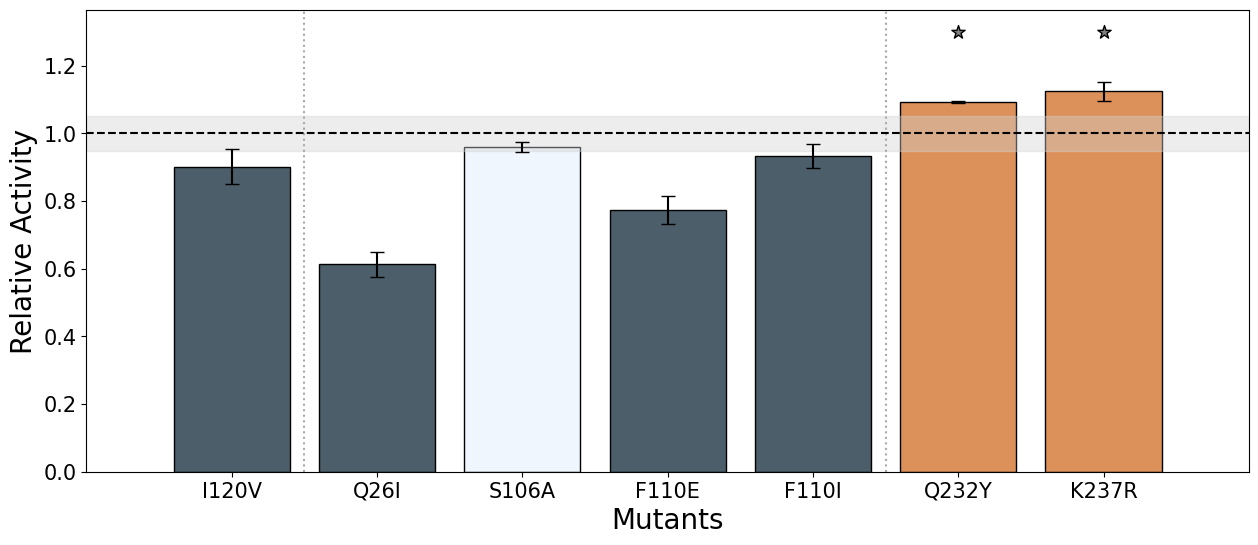

In [704]:
fig, ax= plt.subplots(figsize=(15,6))
width = 0.8
for i,prot in enumerate(subset_2_rateng_pd.Protein):
    #color = target_colors[variant_cat[prot]]
    sig_ = 'Pos' if rat_act_2_res_df.loc[rat_act_2_res_df.Mutant == prot, "Significant"].values[0] else 'Neg' if rat_act_2_neg_res_df.loc[rat_act_2_neg_res_df.Mutant == prot, "Significant"].values[0] else 'WT-like'
    color = sig_colors[sig_]
    x = prot
    ax.bar(x, subset_2_rateng_pd.Relative_Activity_mean[i], yerr=subset_2_rateng_pd.Relative_Activity_std[i],
        capsize=5, edgecolor='black', color=color, width=width)
    
    if sig_ == 'Pos':
        ax.scatter(i, 1.3, color='grey', s=100, edgecolor='black', marker='*', zorder=3)
    #elif sig_ == 'Neg':
    #    ax.scatter(i, 1.3, color='red', s=100, edgecolor='black', marker='x', zorder=3)
    
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel("Mutants", fontsize=20)

for x_ in [0.5,4.5]:
        ax.axvline(x=x_, color='darkgray', linestyle=':')

ax.axhline(y=1, color='black', linestyle='--')
ax.fill_between([-1, len(subset_2_rateng_pd.Protein)], 1 - ref_2_std, 1 + ref_2_std, color='lightgrey', alpha=0.4)
ax.set_xlim(-1, len(subset_2_rateng_pd.Protein))
        
ax.set_ylabel("Relative Activity", fontsize=20)

In [705]:
SAM = 300 ### Selected time, must be element of [10, 300]
t = 2 ### Selected time, must be element of [2, 5, 180]
subset = subset_2_rateng[(subset_2_rateng["Time(min)"] == t) & (subset_2_rateng["SAM_conc(uM)"] == SAM)]
for mut in ["K237R"]:
    relact_ = subset[subset["Protein"]==mut]
    best_mutant_rel[mut] = relact_['Relative_Activity'].values
    best_mutant_conv[mut] = relact_['%SAM_converted'].values

    print(f"{mut}: {relact_['Relative_Activity'].values}, {relact_['%SAM_converted'].values}")

K237R: [1.09106149 1.1434574  1.13629754], [0.45050768 0.47214235 0.46918599]


/var/folders/4n/74gpb5hj01g0m2nkznhtyjrr0000gp/T/ipykernel_27158/2092910848.py:19: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(i, 1.3, color='red', s=100, edgecolor='black', marker='x', zorder=3)


(-0.5, 6.5)

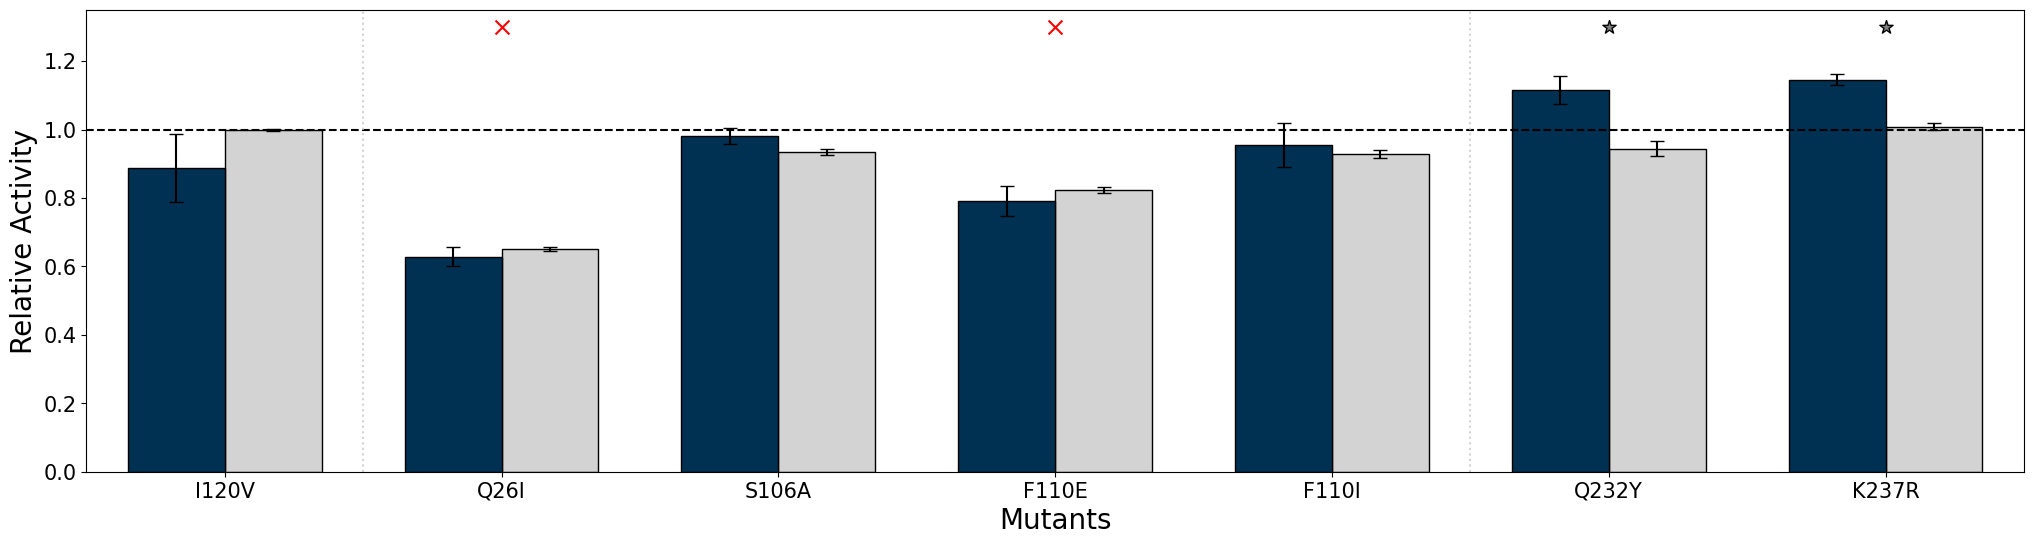

In [43]:
color_ = ['lightgrey','#003052']

fig, ax= plt.subplots(figsize=(25,6))
width = 0.35
x_2 = np.arange(len(subset_2_rateng_pd.Protein))-(width/2)
x_180 = np.arange(len(subset_180_rateng_pd.Protein))+(width/2)
ax.bar(x_180,subset_180_rateng_pd.Relative_Activity_mean, yerr=subset_180_rateng_pd.Relative_Activity_std,
        capsize=5, edgecolor='black', color=color_[0],width=width)
ax.bar(x_2,subset_2_rateng_pd.Relative_Activity_mean, yerr=subset_2_rateng_pd.Relative_Activity_std,
        capsize=5, edgecolor='black', color=color_[1],width=width)

ax.set_xticks(np.arange(len(subset_2_rateng_pd.Protein)))
ax.set_xticklabels(subset_2_rateng_pd.Protein, rotation=0, ha='center')

for i, mut in enumerate(subset_2_rateng_pd.Protein):
        if rat_act_2_res_df.loc[rat_act_2_res_df.Mutant == mut, "Significant"].values[0]:
            ax.scatter(i, 1.3, color='grey', s=100, edgecolor='black', marker='*', zorder=3)
        if rat_act_2_neg_res_df.loc[rat_act_2_neg_res_df.Mutant == mut, "Significant"].values[0]:
                ax.scatter(i, 1.3, color='red', s=100, edgecolor='black', marker='x', zorder=3)

ax.axhline(y=1, color='black', linestyle='--')

    
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel("Mutants", fontsize=20)

for x_ in [0.5,4.5]:
        ax.axvline(x=x_, color='lightgray', linestyle=':')
        
ax.set_ylabel("Relative Activity", fontsize=20)
ax.set_ylim(0, 1.35)
ax.set_xlim(-0.5, len(subset_2_rateng_pd.Protein)-0.5)

## Temperature Curves

In [217]:
tempcurve = pd.read_csv("data/FlA_TempCurve.csv", sep=";")
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Plate"]!="ZP_TempCurve"])
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Protein"]=="Ctrl"])
tempcurve = tempcurve.drop(tempcurve.index[tempcurve["Protein"]=="Quad"])

temp_reference = tempcurve[tempcurve["Protein"] == "WT"]
# Merge the reference values back into the original DataFrame based on the same condition
tempcurve = tempcurve.merge(
    temp_reference[["Plate", "Timepoint", "SAM Conc.", "Temp.", "Replicate", "%SAM converted"]],
    on=["Plate", "Timepoint", "SAM Conc.", "Temp.", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# Calculate Relative_Activity
tempcurve["Relative_Activity"] = tempcurve["%SAM converted"] / tempcurve["%SAM converted_ref"]

# Drop the intermediate reference column 
tempcurve.drop(columns=["%SAM converted_ref"], inplace=True)



tempcurve_conv = pd.melt(tempcurve, id_vars=["Protein", "Temp."], value_vars=["%SAM converted"])


tempcurve_rel = tempcurve.drop(tempcurve.index[tempcurve["Protein"] == "WT"].tolist())
tempcurve_rel = pd.melt(tempcurve_rel, id_vars=["Protein", "Temp."], value_vars=["Relative_Activity"])

for mut in ["WT","H32L","H191E","G37D","S166A"]:
    prev_conv = best_mutant_conv[mut]
    i = tempcurve_conv.shape[0]
    for val in prev_conv:
        tempcurve_conv.loc[i] = [mut, 37, '%SAM converted', val]
        i += 1
    if mut != "WT":
        prev_rel = best_mutant_rel[mut]
        i = tempcurve_rel.shape[0]
        for val in prev_rel:
            tempcurve_rel.loc[i] = [mut, 37, 'Relative_Activity', val]
            i += 1
print(tempcurve_conv[(tempcurve_conv['Protein']=='WT') & (tempcurve_conv['Temp.']==37)])
tempcurve_conv = tempcurve_conv.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()
tempcurve_rel = tempcurve_rel.groupby(by=["Protein", "Temp."])["value"].agg(["mean", "std"]).reset_index()

   Protein  Temp.        variable     value
0       WT     37  %SAM converted  1.458370
6       WT     37  %SAM converted  1.557037
72      WT     37  %SAM converted  1.200619
73      WT     37  %SAM converted  1.242053
74      WT     37  %SAM converted  1.335500
75      WT     37  %SAM converted  1.335500
76      WT     37  %SAM converted  1.335500
77      WT     37  %SAM converted  1.307957
78      WT     37  %SAM converted  1.307957
79      WT     37  %SAM converted  1.307957
80      WT     37  %SAM converted  1.306585
81      WT     37  %SAM converted  1.306585
82      WT     37  %SAM converted  1.287540
83      WT     37  %SAM converted  1.543873


In [212]:
colors_temp = {
    62: "#DF9966",
    57: "#FFC49B",
    52: "#FFEFD3",
    47: "#ADB6C4",
    42: "#3B6F8D",
    37: "#001B2E",
}

In [225]:
# Order categories
#protein_order = ["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"]
protein_order = ["WT", "S166A", "H191E", "H32L", "G37D", "K237R"]
temp_order = [37, 42, 47, 52, 57, 62]


tempcurve_conv["Protein"] = pd.Categorical(
    tempcurve_conv["Protein"], categories=protein_order, ordered=True
)
tempcurve_conv["Temp."] = pd.Categorical(
    tempcurve_conv["Temp."], categories=temp_order, ordered=True
)
tempcurve_conv = tempcurve_conv.sort_values(["Protein", "Temp."])


tempcurve_rel['Protein'] = pd.Categorical(
    tempcurve_rel['Protein'], categories=protein_order, ordered=True
)
tempcurve_rel['Temp.'] = pd.Categorical(
    tempcurve_rel['Temp.'], categories=temp_order, ordered=True
)
tempcurve_rel = tempcurve_rel.sort_values(["Protein", "Temp."])

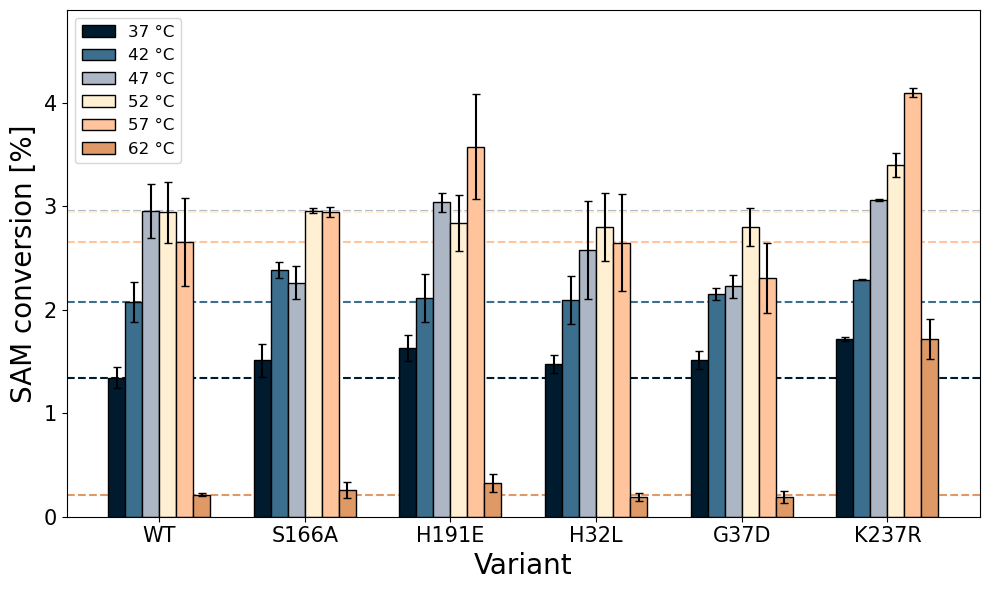

In [228]:
# Grouped bar plot
proteins = tempcurve_conv["Protein"].unique()
temps = tempcurve_conv["Temp."].unique()
x = np.arange(len(proteins))  # X locations for variants
width = 0.7  # Bar width (adjust if more temps)

fig, ax = plt.subplots(figsize=(10, 6))

for i, t in enumerate(temps):
    subset = tempcurve_conv[tempcurve_conv["Temp."] == t]
    ax.bar(
        x + i * width/len(temps),
        subset["mean"],
        yerr=subset["std"],
        width=width/len(temps),
        label=f"{t} °C",
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=colors_temp[t],
        zorder=2
    )
# Labels and title
ax.set_xlabel("Variant",fontsize=20)
ax.set_ylabel("SAM conversion [%]",fontsize=20)
ax.set_xticks(x + width/2 - width/(2*len(temps)))
ax.set_xticklabels(proteins, rotation=0, ha="center")
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

# Add horizontal line at WT values
for i,row in tempcurve_conv[tempcurve_conv["Protein"] == "WT"].iterrows():
    wt_value = row['mean']
    t = row['Temp.']
    ax.axhline(y=wt_value, linestyle="--",color=colors_temp[t],zorder=1)

ax.set_ylim(0, 4.9)

plt.tight_layout()
plt.show()


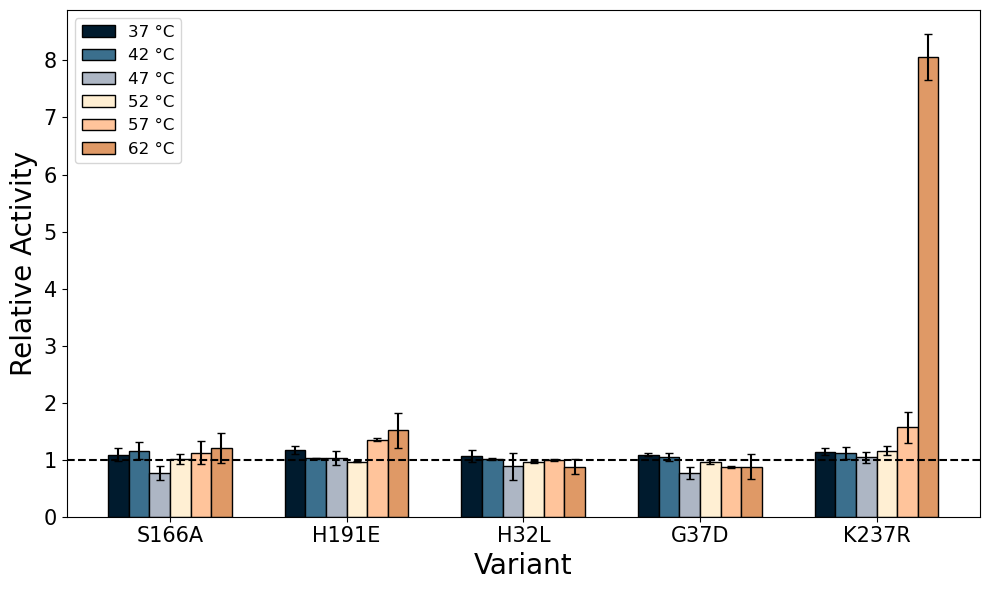

In [229]:
# Grouped bar plot
proteins = tempcurve_rel["Protein"].unique()
temps = tempcurve_rel["Temp."].unique()
x = np.arange(len(proteins))  # X locations for variants
width = 0.7  # Bar width (adjust if more temps)

fig, ax = plt.subplots(figsize=(10, 6))

for i, t in enumerate(temps):
    subset = tempcurve_rel[tempcurve_rel["Temp."] == t]
    ax.bar(
        x + i * width/len(temps),
        subset["mean"],
        yerr=subset["std"],
        width=width/len(temps),
        label=f"{t} °C",
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=colors_temp[t],
    )

# Add horizontal line at y=1
ax.axhline(y=1, color="black", linestyle="--")

# Labels
ax.set_xlabel("Variant",fontsize=20)
ax.set_ylabel("Relative Activity",fontsize=20)
ax.set_xticks(x + width/2 - width/(2*len(temps)))
ax.set_xticklabels(proteins, rotation=0, ha="center")
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

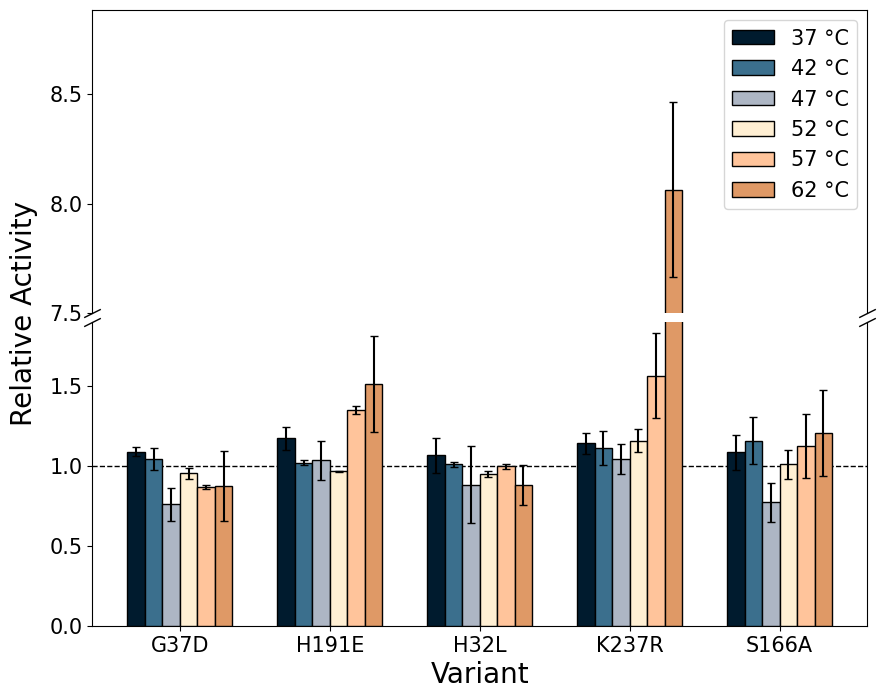

In [219]:
# --- your existing inputs ---
proteins = tempcurve_rel["Protein"].unique()
temps     = tempcurve_rel["Temp."].unique()
x = np.arange(len(proteins))
width = 0.70

# pick the cut ranges
bottom_ylim = (0.0, 1.9)  # most bars
y_max = float((tempcurve_rel["mean"] + tempcurve_rel["std"]).max())
top_ylim    = (7.5, max(8.6, y_max * 1.05))  # outlier region

# helper to draw grouped bars on a given axis
def draw_grouped(ax):
    for i, t in enumerate(temps):
        sub = tempcurve_rel[tempcurve_rel["Temp."] == t]
        ax.bar(
            x + i * width/len(temps),
            sub["mean"],
            yerr=sub["std"],
            width=width/len(temps),
            label=f"{t} °C",
            edgecolor="black",
            linewidth=1.0,
            capsize=3,
            color=colors_temp[t],
            zorder=3
        )

# ---- template-style broken axis ----
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
fig.subplots_adjust(hspace=0.03)  # space between axes

# plot same bars on both axes
draw_grouped(ax1)
draw_grouped(ax2)

# zoom / limits (top = outliers, bottom = bulk)
ax1.set_ylim(*top_ylim)
ax2.set_ylim(*bottom_ylim)

# reference line on bottom panel
ax2.axhline(1.0, color="black", linestyle="--", linewidth=1, zorder=2)

# hide the spines between the two axes, set ticks like in the template
ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(top=False, labeltop=False)
ax2.xaxis.tick_bottom()

# slanted break markers (exact template approach)
d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# labels / ticks / legend
ax2.set_xlabel("Variant", fontsize=20)
ax2.set_xticks(x + width/2 - width/(2*len(temps)))
ax2.set_xticklabels(proteins, rotation=0, ha="center")

ax1.set_yticks(np.arange(top_ylim[0], top_ylim[1], 0.5))

ax1.set_ylabel("Relative Activity", fontsize=20)
ax1.yaxis.set_label_coords(-0.07, 0)

ax1.tick_params(axis="y", labelsize=15)
ax2.tick_params(axis="both", which="major", labelsize=15)

# legend once (top-left above bottom axis)
ax1.legend(fontsize=15)


#plt.tight_layout()
plt.show()



In [73]:
top_ylim
np.arange(top_ylim[0], top_ylim[1], 0.5)

array([7.5, 8. , 8.5])

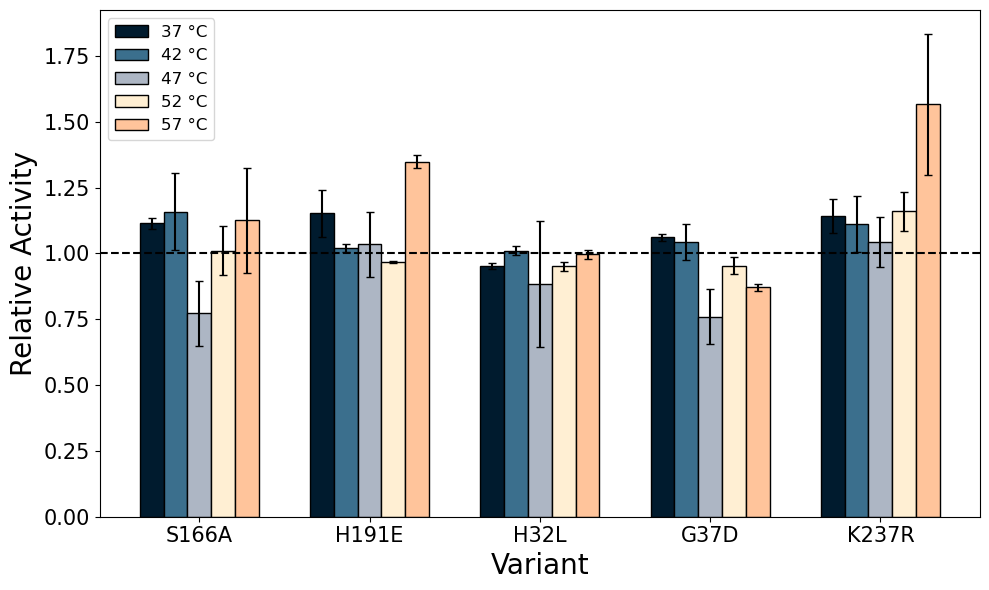

In [74]:
# Grouped bar plot
proteins = tempcurve_rel["Protein"].unique()
temps = tempcurve_rel["Temp."].unique()
x = np.arange(len(proteins))  # X locations for variants
width = 0.7  # Bar width (adjust if more temps)

fig, ax = plt.subplots(figsize=(10, 6))

for i, t in enumerate(temps[:-1]):
    subset = tempcurve_rel[tempcurve_rel["Temp."] == t]
    ax.bar(
        x + i * width/len(temps[:-1]),
        subset["mean"],
        yerr=subset["std"],
        width=width/len(temps[:-1]),
        label=f"{t} °C",
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=colors_temp[t],
    )

# Add horizontal line at y=1
ax.axhline(y=1, color="black", linestyle="--")

# Labels
ax.set_xlabel("Variant",fontsize=20)
ax.set_ylabel("Relative Activity",fontsize=20)
ax.set_xticks(x + width/2 - width/(2*len(temps[:-1])))
ax.set_xticklabels(proteins, rotation=0, ha="center")
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()

## Product Inhibition

In [52]:
product_inhib = pd.read_csv("data/FlA_ZP_PI.csv", sep=";")
product_inhib = product_inhib.drop(product_inhib.index[product_inhib["Protein"]=="Ctrl"])
product_inhib_reference = product_inhib[product_inhib["Protein"] == "WT"]

In [53]:
# Merge the reference values back into the original DataFrame based on the same condition
product_inhib = product_inhib.merge(
    product_inhib_reference[["Plate",'Protein', "FDA Conc.", "Replicate", "FDA Corr. -ctrl"]],
    on=["Plate", "FDA Conc.", "Replicate"],
    suffixes=("", "_ref"),
    how="left"
)

# Calculate Relative_Activity
product_inhib["Relative_Activity"] = product_inhib["FDA Corr. -ctrl"] / product_inhib["FDA Corr. -ctrl_ref"]

# Drop the intermediate reference column
product_inhib.drop(columns=["FDA Corr. -ctrl_ref"], inplace=True)



product_inhib_conv = pd.melt(product_inhib, id_vars=["Protein", "FDA Conc."], value_vars=["FDA Corr. -ctrl"])
product_inhib_conv = product_inhib_conv.groupby(by=["Protein", "FDA Conc."])["value"].agg(["mean", "std"]).reset_index()

product_inhib_rel = product_inhib.drop(product_inhib.index[product_inhib["Protein"] == "WT"].tolist())
product_inhib_rel = pd.melt(product_inhib_rel, id_vars=["Protein", "FDA Conc."], value_vars=["Relative_Activity"])
product_inhib_rel = product_inhib_rel.groupby(by=["Protein", "FDA Conc."])["value"].agg(["mean", "std"]).reset_index()

In [54]:
# Order categories
protein_order = ["WT", "S166A", "H191E", "H32L", "G37D", "Quad", "K237R"]
FDA_order = product_inhib_conv['FDA Conc.'].unique()


product_inhib_conv["Protein"] = pd.Categorical(
    product_inhib_conv["Protein"], categories=protein_order, ordered=True
)
product_inhib_conv['FDA Conc.'] = pd.Categorical(
    product_inhib_conv['FDA Conc.'], categories=FDA_order, ordered=True
)
product_inhib_conv = product_inhib_conv.sort_values(["Protein", 'FDA Conc.'])


product_inhib_rel["Protein"] = pd.Categorical(
    product_inhib_rel["Protein"], categories=protein_order, ordered=True
)
product_inhib_rel['FDA Conc.'] = pd.Categorical(
    product_inhib_rel['FDA Conc.'], categories=FDA_order, ordered=True
)
product_inhib_rel = product_inhib_rel.sort_values(["Protein", 'FDA Conc.'])

In [55]:
colors_PI = {
    0: "#DF9966",
    50: "#FFEFD3",
    100: "#ADB6C4",
    200: "#001B2E",
}

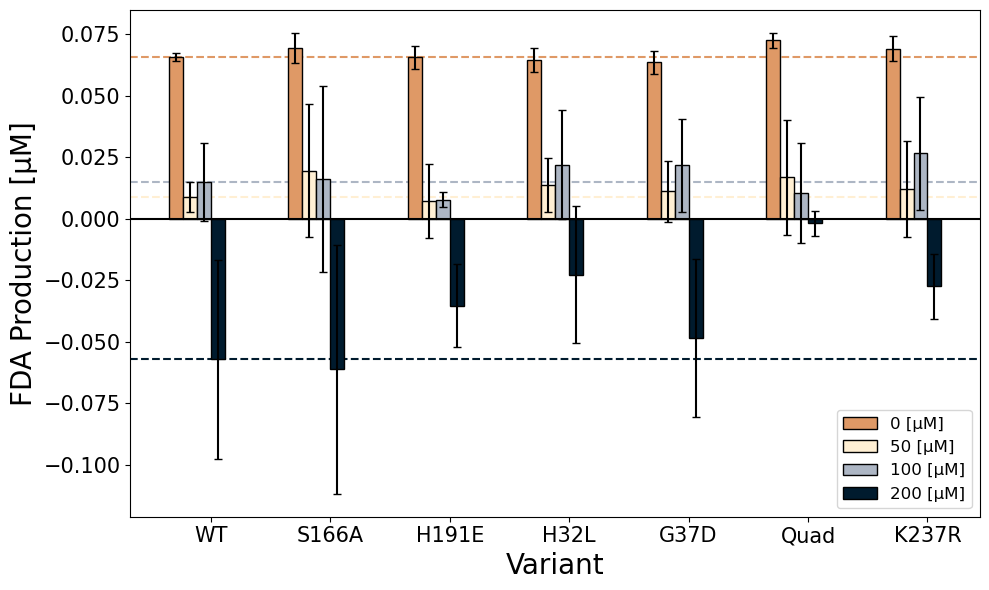

In [56]:
# Grouped bar plot
proteins = product_inhib_conv["Protein"].unique()
x = np.arange(len(proteins))  # X locations for variants
width = 0.7  # Bar width (adjust if more temps)

fig, ax = plt.subplots(figsize=(10, 6))

for i, t in enumerate(FDA_order):
    subset = product_inhib_conv[product_inhib_conv["FDA Conc."] == t]
    ax.bar(
        x + i * width/len(temps),
        subset["mean"],
        yerr=subset["std"],
        width=width/len(temps),
        label=f"{t} [µM]",
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=colors_PI[t],
        zorder=2
    )
# Labels and title
ax.set_xlabel("Variant",fontsize=20)
ax.set_ylabel("FDA Production [µM]",fontsize=20)
ax.set_xticks(x + width/2 - width/(2*len(temps)))
ax.set_xticklabels(proteins, rotation=0, ha="center")
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=15)

# Add horizontal line at WT values
for i,row in product_inhib_conv[product_inhib_conv["Protein"] == "WT"].iterrows():
    wt_value = row['mean']
    t = row['FDA Conc.']
    ax.axhline(y=wt_value, linestyle="--",color=colors_PI[t],zorder=1)

ax.axhline(y=0, linestyle="-",color='black',zorder=3)

plt.tight_layout()
plt.show()